# **1 - Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **2 - Importing the necessary libraries**

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
import time


# For splitting the dataset
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
    make_scorer
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi, create_repo

# for managging environment variables
from dotenv import load_dotenv

## Setting Constant Variables

In [2]:
# Dataset path
FOLDER = "data/"
FILE = "SuperKart.csv"

# Batch File path
BATCH_FILE = "batch_data_superkart.csv"

# Random seed
RS = 42

# Hugging Face API Key
load_dotenv()
API_KEY = os.getenv("HF_API_KEY")


# **3 - Loading the dataset**

In [3]:
# Load the dataset
data = pd.read_csv(FOLDER + FILE)
# Keep a copy of the original data
df = data.copy()

# **4 - Data Overview**

In [4]:
# Display the first 5 rows of the dataset
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [5]:
# Display the last 5 rows of the dataset
df.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


In [6]:
# Display the shape of the dataset
df.shape

(8763, 12)

The dataset has 8763 rows and 12 columns.

In [7]:
# Display the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


- The dataset has 5 numeric features (4 float and 1 integer), and 7 object type features. 
- The dataset has 8763 observations and it appears that there are no missing values. 

## Understanding each feature

### Product_Id

In [8]:
# Number of unique products in the dataset
df["Product_Id"].nunique()

8763

- The Product ID serves solely as a unique identifier for each observation and does not convey predictive information relevant to the modeling task. Consequently, this feature can be excluded from the dataset during preprocessing without compromising model performance.

### Product_Sugar_Content

In [9]:
# Value counts of the Product_Sugar_Content column
df["Product_Sugar_Content"].value_counts()

Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64

- The Product Sugar Content variable comprises four distinct values. The most frequently occurring category is Low Sugar (n = 4,885), followed by Regular (n = 2,251) and No Sugar (n = 1,519). Additionally, 108 entries are labeled as reg, which is presumed to be a shorthand for Regular. To maintain categorical consistency and avoid misclassification, these instances should be recoded to align with the Regular category rather than treated as a separate class.

In [10]:
# Recode 'reg' to 'Regular' in the 'Product_Sugar_Content' column
df['Product_Sugar_Content'] = df['Product_Sugar_Content'].replace({'reg': 'Regular'})

In [11]:
# Value counts of the Product_Sugar_Content column
df["Product_Sugar_Content"].value_counts()

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64

- Following the recoding of the reg label to align with the Regular category, the Product Sugar Content variable now comprises three distinct and standardized categories: Low Sugar (n = 4,885), Regular (n = 2,359), and No Sugar (n = 1,519).

### Product_Type

In [12]:
# Value counts of the Product_Type column
df["Product_Type"].value_counts()

Product_Type
Fruits and Vegetables    1249
Snack Foods              1149
Frozen Foods              811
Dairy                     796
Household                 740
Baking Goods              716
Canned                    677
Health and Hygiene        628
Meat                      618
Soft Drinks               519
Breads                    200
Hard Drinks               186
Others                    151
Starchy Foods             141
Breakfast                 106
Seafood                    76
Name: count, dtype: int64

- The Product_Type feature includes 16 distinct categories, with Fruits and Vegetables and Snack Foods being the most common. The distribution reflects a mix of perishable, staple, and specialized goods.

### Store_Id

In [13]:
# Value counts of the Store_Id column
df["Store_Id"].value_counts()

Store_Id
OUT004    4676
OUT001    1586
OUT003    1349
OUT002    1152
Name: count, dtype: int64

- The Store_Id feature identifies the retail outlet associated with each observation and comprises four unique store codes. The distribution is notably imbalanced, with OUT004 representing the majority of entries (n = 4,676), followed by OUT001 (n = 1,586), OUT003 (n = 1,349), and OUT002 (n = 1,152).

### Store_Size

In [14]:
# Value counts of the Store_Size column
df["Store_Size"].value_counts()

Store_Size
Medium    6025
High      1586
Small     1152
Name: count, dtype: int64

- The Store_Size feature categorizes outlets by their physical scale and comprises three distinct levels: Medium (n = 6,025), High (n = 1,586), and Small (n = 1,152).

### Store_Location_City_Type

In [15]:
# Value counts of the Store_Location_City_Type column
df["Store_Location_City_Type"].value_counts()

Store_Location_City_Type
Tier 2    6262
Tier 1    1349
Tier 3    1152
Name: count, dtype: int64

- The Store_Location_City_Type feature categorizes outlets by urban tier classification, comprising three levels: Tier 2 (n = 6,262), Tier 1 (n = 1,349), and Tier 3 (n = 1,152).

### Store_Type

In [16]:
# Value counts of the Store_Type column
df["Store_Type"].value_counts()

Store_Type
Supermarket Type2     4676
Supermarket Type1     1586
Departmental Store    1349
Food Mart             1152
Name: count, dtype: int64

- The Store_Type feature comprises four distinct retail formats. Supermarket Type2 is the most prevalent (n = 4,676), followed by Supermarket Type1 (n = 1,586), Departmental Store (n = 1,349), and Food Mart (n = 1,152).

## Duplicate Values

In [17]:
# Check for duplicate values in the dataset
df.duplicated().sum()

np.int64(0)

- The dataset has no duplicate values

## Missing Values

In [18]:
# Check for missing values in the data
df.isna().sum()

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

- The dataset has no missing values

## Statistical Summary

In [19]:
# Statistical summary of numerical columns
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


The dataset comprises 8,763 observations across five continuous variables, each exhibiting distinct statistical properties. 
- **Product_Weight** has a mean of 12.65 kg and a standard deviation of 2.22, with values ranging from 4.00 to 22.00 kg, indicating moderate variability in product mass.
- **Product_Allocated_Area** displays a low average (0.0688) and relatively high dispersion, suggesting substantial heterogeneity in shelf space allocation.
- **Product_MRP** (Maximum Retail Price) presents a mean of 147.03 units and spans a wide range from 31.00 to 266.00 units, reflecting diverse pricing strategies.
- **Store_Establishment_Year** centers around 2002, with a standard deviation of 8.39 years and a maximum value of 2009, indicating a concentration of store openings in the early 2000s.
- **Product_Store_Sales_Total** exhibits considerable variation, with a mean of 3,464 units and a range from 33.00 to 8,000.00 units, underscoring disparities in product-level sales performance across the dataset.

In [20]:
# Statistical summary of categorical columns
df.describe(include='object').T

,count,unique,top,freq
Product_Id,8763,8763,FD306,1
Product_Sugar_Content,8763,3,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


The categorical summary reflects the composition and frequency distribution of key variables across 8,763 observations. 
- **Product_Id** exhibits complete uniqueness, serving as a distinct identifier for each entry.
- **Product_Sugar_Content** comprises four categories, with Low Sugar being the most prevalent (n = 4,885).
- **Product_Type** includes 16 distinct classifications, dominated by Fruits and Vegetables (n = 1,249), indicating a diverse product assortment.
- **Store_Id** spans four unique outlets, with OUT004 accounting for the majority (n = 4,676), suggesting a concentration of data from a single store. 
- **Store_Size** is categorized into three levels, with Medium stores most frequently represented (n = 6,025).
- **Store_Location_City_Type** is skewed toward Tier 2 cities (n = 6,262), reflecting a predominance of mid-tier urban settings. 
- **Store_Type** includes four retail formats, with Supermarket Type2 being the most common (n = 4,676), indicating a dataset primarily composed of large-format grocery outlets.

# **6 - Exploratory Data Analysis (EDA)**

#### Plot Functions

In [21]:
def plot_numerical_distributions(data, numerical_features, hue=None, figsize=(16, 12), dpi=100, bins=30, palette="viridis", plot_style="whitegrid", show_median=True):
    
    # Set style and palette
    sns.set_style(plot_style)
    sns.set_palette(palette)
    
    # Calculate grid dimensions
    n_cols = 2
    n_rows = (len(numerical_features) // n_cols) + (1 if len(numerical_features) % n_cols else 0)
    
    # Create figure
    fig = plt.figure(figsize=figsize, dpi=dpi)
    fig.suptitle('Distribution Analysis', y=1.02, fontsize=16, fontweight='bold')
    
    for i, feature in enumerate(numerical_features, 1):
        ax = plt.subplot(n_rows, n_cols, i)
        
        # Plot histogram with KDE
        sns.histplot(data=data, x=feature, hue=hue, kde=True, bins=bins, edgecolor='white', linewidth=0.5, stat='count', alpha=0.7)
        
        # Add median line
        if show_median:
            median = data[feature].median()
            ax.axvline(median, color='red', linestyle='--', linewidth=1.5)
            x_offset = 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])  # 2% of x-axis range
            ax.text(median + x_offset, ax.get_ylim()[1]*0.9, f'Median: {median:.1f}', color='red', va='top')
        
        # Formatting
        ax.set_title(f'{feature} Distribution', pad=10)
        ax.set_xlabel('')
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    
    return fig

In [22]:
def plot_numerical_boxplots(data, numerical_features, figsize=(16, 12), palette="viridis", plot_style="whitegrid", showfliers=True, notch=False, orient="v", hue=None):

    # Set visual style
    sns.set_style(plot_style)
    plt.rcParams['font.size'] = 12
    
    # Calculate grid dimensions
    n_cols = 2
    n_rows = (len(numerical_features) // n_cols) + (1 if len(numerical_features) % n_cols else 0)
    
    # Initialize figure
    fig = plt.figure(figsize=figsize, dpi=100, layout="constrained")
    fig.suptitle('Numerical Features Distribution Analysis (Boxplots)', fontsize=18, fontweight='bold', y=1.02)
    
    # Create subplots
    for idx, feature in enumerate(numerical_features, start=1):
        ax = fig.add_subplot(n_rows, n_cols, idx)
        
        # Plot boxplot with enhanced aesthetics
        sns.boxplot(
            data=data,
            x=feature if orient == "v" else None,
            y=None if orient == "v" else feature,
            hue=hue,
            palette=palette,
            width=0.6,
            showfliers=showfliers,
            notch=notch,
            linewidth=1.5,
            fliersize=3,
            saturation=0.8
        )
        

        
        # Add mean marker
        mean_val = data[feature].mean()
        if orient == "v":
            ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}')
        else:
            ax.axhline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}')
        ax.legend(loc='upper right')
        
        # Format subplot
        ax.set_title(f'{feature} Distribution', pad=12, fontweight='semibold')
        if orient == "v":
            ax.set_ylabel('Value', fontsize=12)
        else:
            ax.set_xlabel('Value', fontsize=12)
        ax.grid(visible=True, alpha=0.2, axis='y' if orient == "v" else 'x')
        
        # Remove top/right spines
        sns.despine(ax=ax, top=True, right=True)
    
    # Add figure caption
    caption = "Note: Red dashed line shows mean value. Box shows IQR (25th-75th percentile)"
    if showfliers:
        caption += ". Points show outliers."
    if hue:
        caption += f" Grouped by {hue}."
    fig.text(
        0.5, 0.01,
        caption,
        ha='center',
        fontsize=12,
        color='dimgray'
    )
    
    return fig

In [23]:
def plot_categorical_distributions(data, categorical_features, hue="",figsize=(16, 18), palette="viridis", plot_style="whitegrid", annotate=True, rotate_labels=False):
    # Set visual style
    sns.set_style(plot_style)
    plt.rcParams['font.size'] = 12
    
    # Calculate grid dimensions
    n_cols = 2
    n_rows = (len(categorical_features) // n_cols) + (1 if len(categorical_features) % n_cols else 0)
    
    # Initialize figure
    fig = plt.figure(figsize=figsize, dpi=100, layout="constrained")
    fig.suptitle('Distribution Analysis', fontsize=18, fontweight='bold', y=1.02)
    
    # Create subplots
    for idx, feature in enumerate(categorical_features, start=1):
        ax = fig.add_subplot(n_rows, n_cols, idx)
        
        # Plot with improved aesthetics
        if hue:
            # If hue is provided, use countplot with hue
            plot = sns.countplot(data=data, x=feature, hue=hue, palette=palette, edgecolor='black', linewidth=0.5, alpha=0.85)
        else:
            # If no hue is provided, use countplot without hue
            plot = sns.countplot(data=data, x=feature, palette=palette, edgecolor='black', linewidth=0.5, alpha=0.85, order=data[feature].value_counts().index)  # Sort by frequency
        
        # Add count annotations
        if annotate:
            for p in ax.patches:
                ax.annotate(
                    f'{p.get_height():,.0f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=10
                )
        
        # Rotate labels if needed
        if rotate_labels:
            plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Format subplot
        ax.set_title(f'{feature} Distribution', pad=12, fontweight='semibold')
        ax.set_xlabel('')
        ax.set_ylabel('Count', fontsize=12)
        ax.grid(visible=True, alpha=0.2, axis='y')
        
        # Remove top/right spines
        sns.despine(ax=ax, top=True, right=True)
        
    return fig

In [24]:
def plot_sales_sum_multiple_categories(df, category_cols, ncols=2, figsize=(14,8), palette='viridis'):
    """
    Creates barplots of the SUM of Product_Store_Sales_Total grouped by multiple categorical variables.
    Each categorical variable is plotted in its own subplot.

    Parameters
    ----------
    df : pandas.DataFrame
        The dataset containing the variables.
    category_cols : list of str
        List of categorical column names to plot.
    ncols : int, optional (default=2)
        Number of subplot columns.
    figsize : tuple, optional
        Size of the matplotlib figure.
    palette : str, optional
        Color palette for the barplots.
    """
    
    nrows = (len(category_cols) + ncols - 1) // ncols  # compute rows needed
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()  # flatten axes for easy iteration
    
    for i, col in enumerate(category_cols):
        # Aggregate sales by category (sum only)
        grouped = df.groupby(col)['Product_Store_Sales_Total'].sum().reset_index()
        grouped = grouped.sort_values('Product_Store_Sales_Total', ascending=False)
        
        # Plot
        sns.barplot(
            data=grouped,
            x=col,
            y='Product_Store_Sales_Total',
            palette=palette,
            ax=axes[i]
        )
        axes[i].set_title(f'Total Sales by {col}', fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Total Sales')
        axes[i].tick_params(axis='x', rotation=45)
    
    # Remove unused subplots if any
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

## Univariate Analysis

In [25]:
# List of numerical and categorical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()
print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total']
Categorical columns: ['Product_Id', 'Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


### Numerical Features Distribution

Although Store Establishment Year is stored as an integer and thus classified as a numerical variable, it represents the year in which a store was opened. Accordingly, it is more appropriate to treat this feature as categorical rather than continuous.

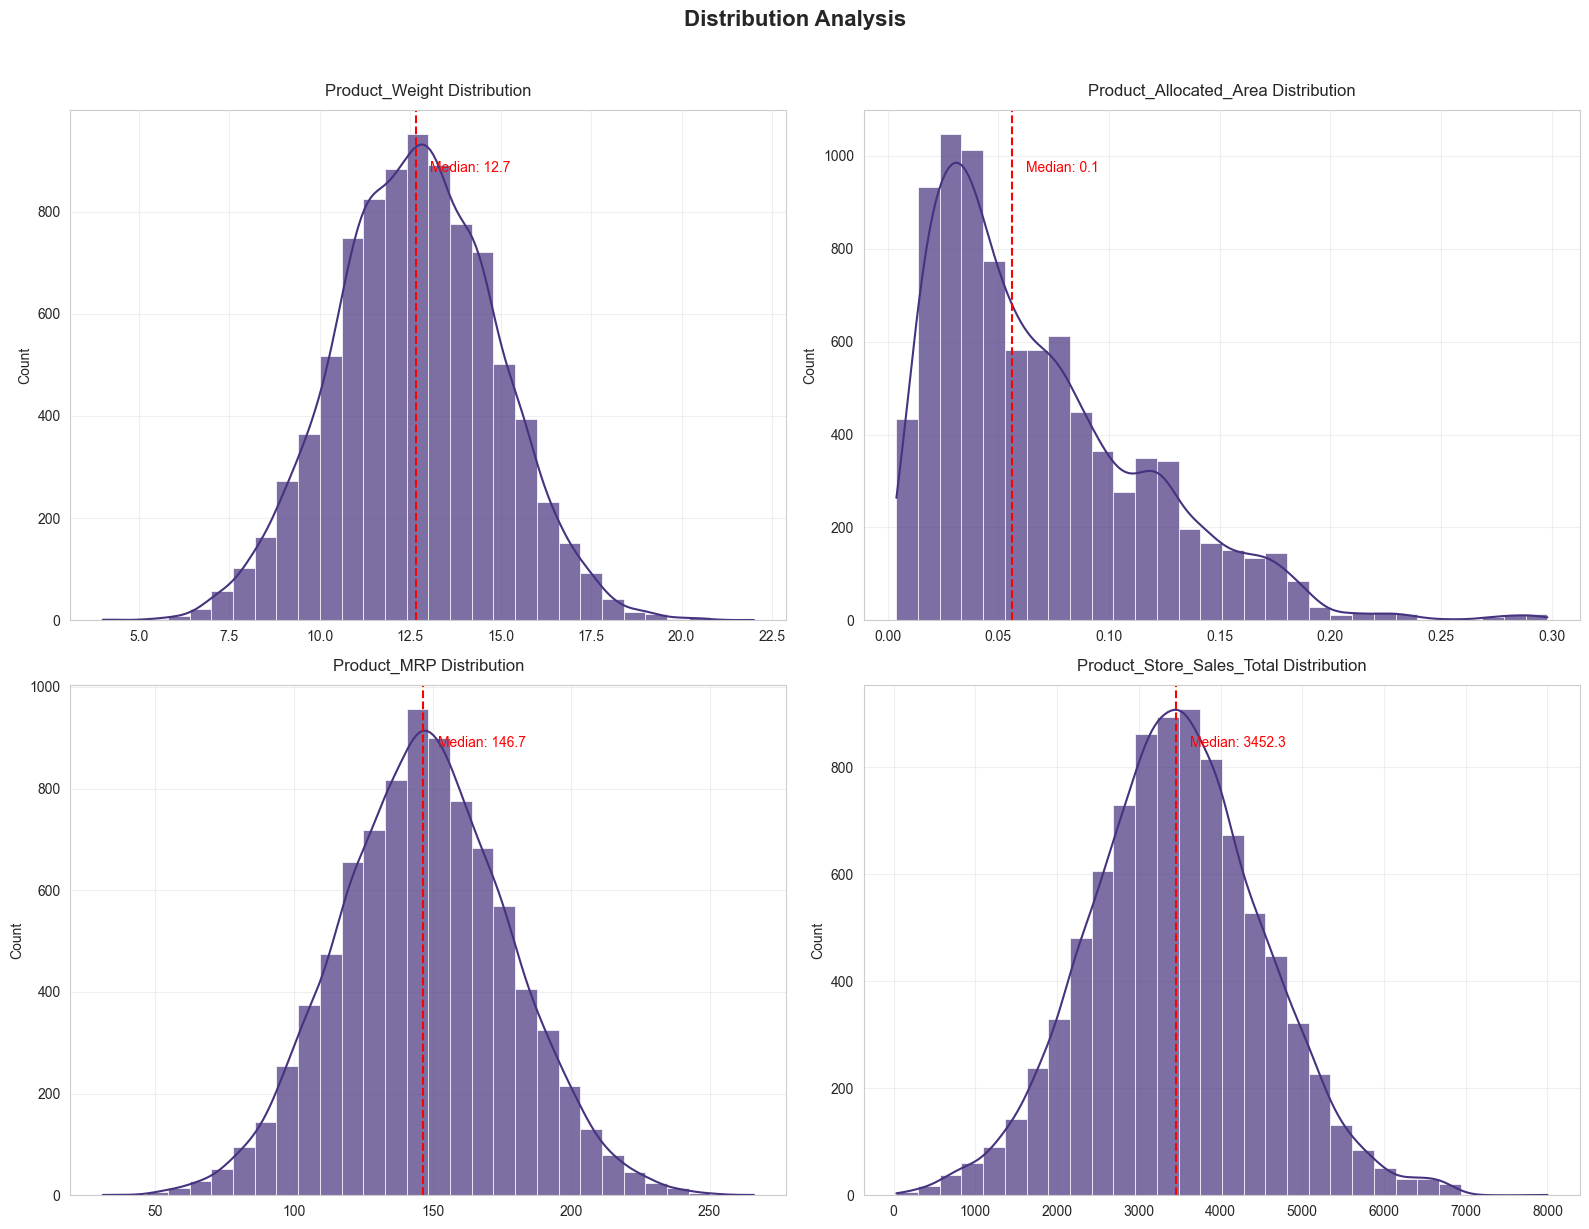

In [26]:
# Remove 'Store_Establishment_Year' from numerical columns for plotting
plot_numeric = numeric_columns.copy()
plot_numeric.remove('Store_Establishment_Year')

# Plot Histograms for numerical features
fig = plot_numerical_distributions(df, plot_numeric)

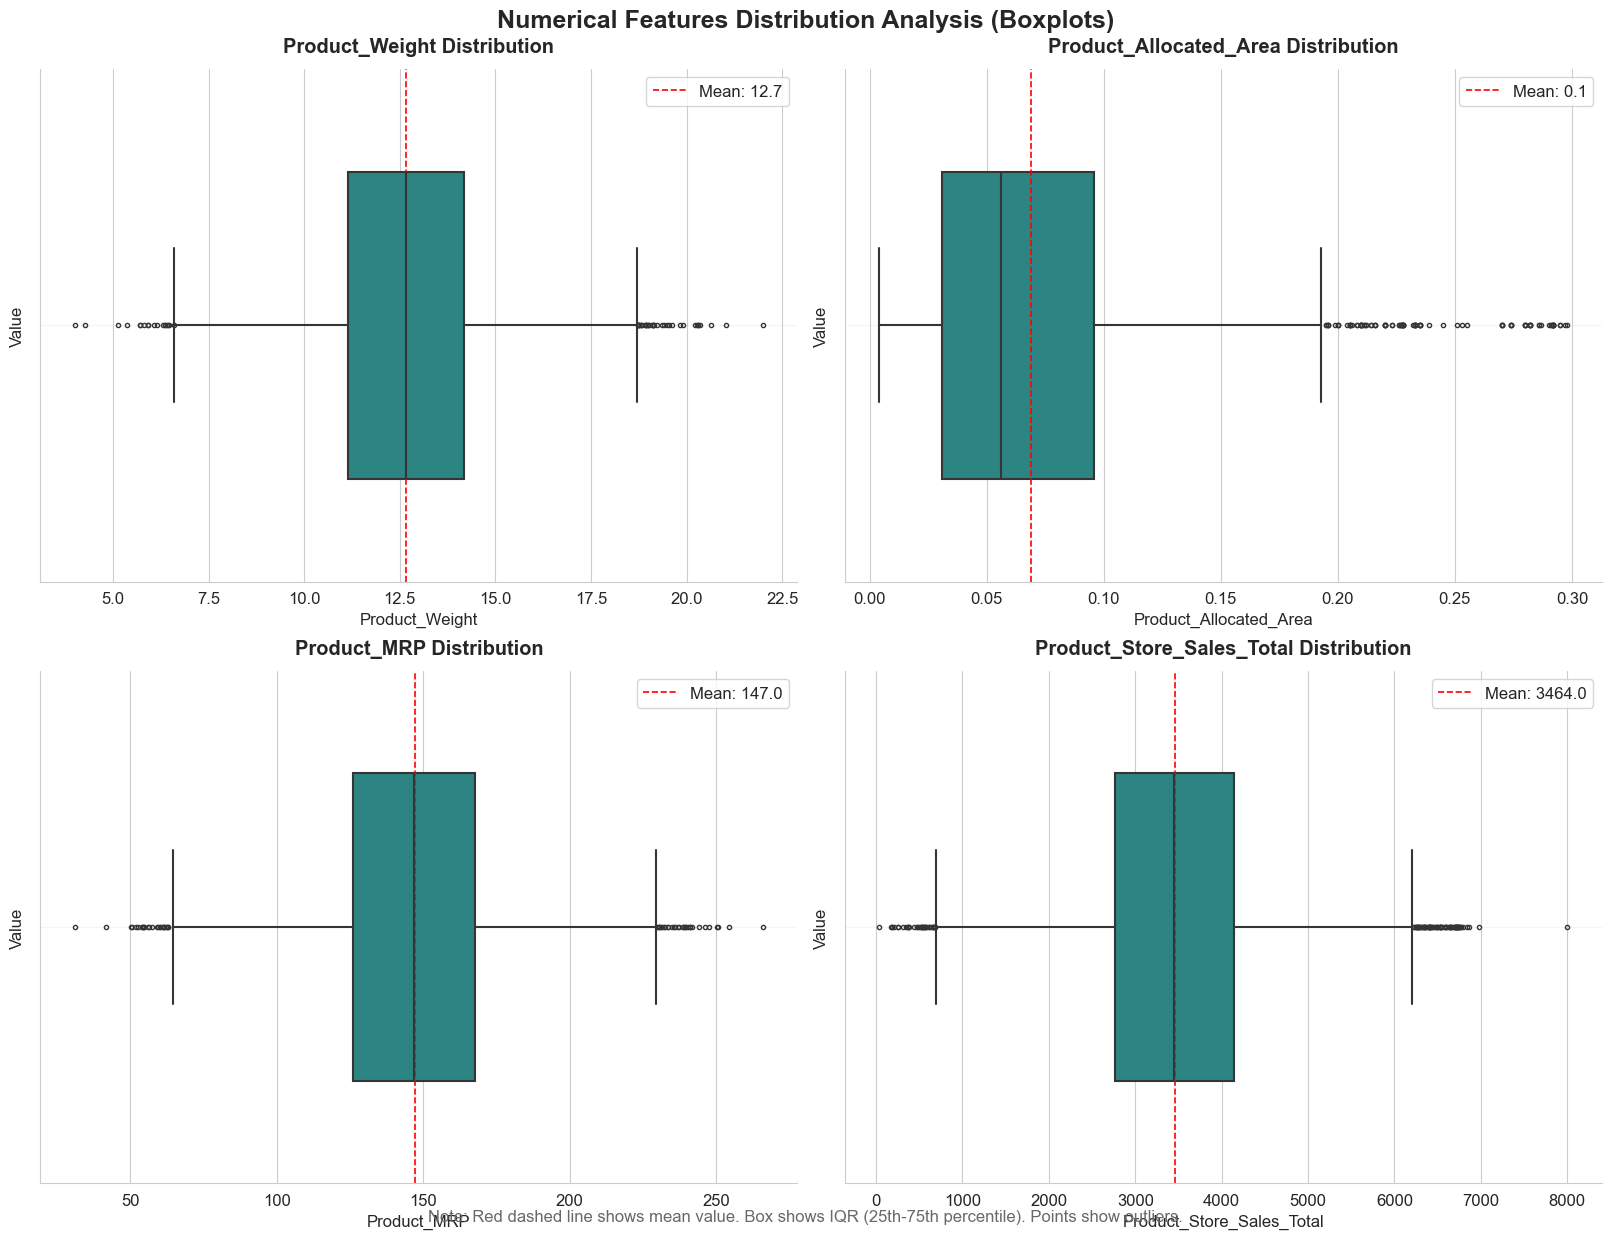

In [27]:
# Plot Boxplots for numerical features
fig = plot_numerical_boxplots(df, plot_numeric)

#### Univariate Analysis Observations (Numerical Features)
---
**Product_Weight**
- Central tendency & spread: Mean = 12.65, Median = 12.66, Std = 2.22.
- Distribution shape: Approximately normal, centered around 12–13 kg.
- Range: 4.00 to 22.00 kg.
- Outliers: A few higher weights (>20 kg) appear as mild outliers in the boxplot.
- This feature is well-behaved, symmetric, and suitable for direct use in modeling with minimal transformation.

**Product_Allocated_Area**
- Central tendency & spread: Mean = 0.069, Median = 0.056, Std = 0.048.
- Distribution shape: Strong right skew, with most products allocated <0.1 area.
- Range: 0.004 to 0.298.
- Outliers: Several extreme values in the upper tail, as shown in the boxplot.
- Highly skewed; normalization may improve model performance.

**Product_MRP**
- Central tendency & spread: Mean = 147.03, Median = 146.74, Std = 30.69.
- Distribution shape: Approximately normal with slight right skew.
- Range: 31.00 to 266.00.
- Outliers: Some higher-priced products, but not extreme relative to the range.
- Stable distribution, scaling might be beneficial.

**Product_Store_Sales_Total**
- Central tendency & spread: Mean = 3,464, Median = 3,452, Std = 1,066.
- Distribution shape: Right-skewed, with most sales between ~2,700 and ~4,100.
- Range: 33 to 8,000.
- Outliers: Several very high sales values (>6,000) are visible in the boxplot.
- Skewness and extreme values suggest potential benefit from log transformation to stabilize variance.
- **This is the target variable.** 


### Categorical Variables Frequencies

Since Product_ID functions solely as a unique identifier, it does not provide analytical value and is therefore unnecessary to plot. In contrast, Store_Establishment_Year will be incorporated into the categorical plots for further analysis.

In [28]:
# Set the categorical columns for plotting
plot_categorical = categorical_columns.copy()
plot_categorical.remove('Product_Id')
plot_categorical.append('Store_Establishment_Year')

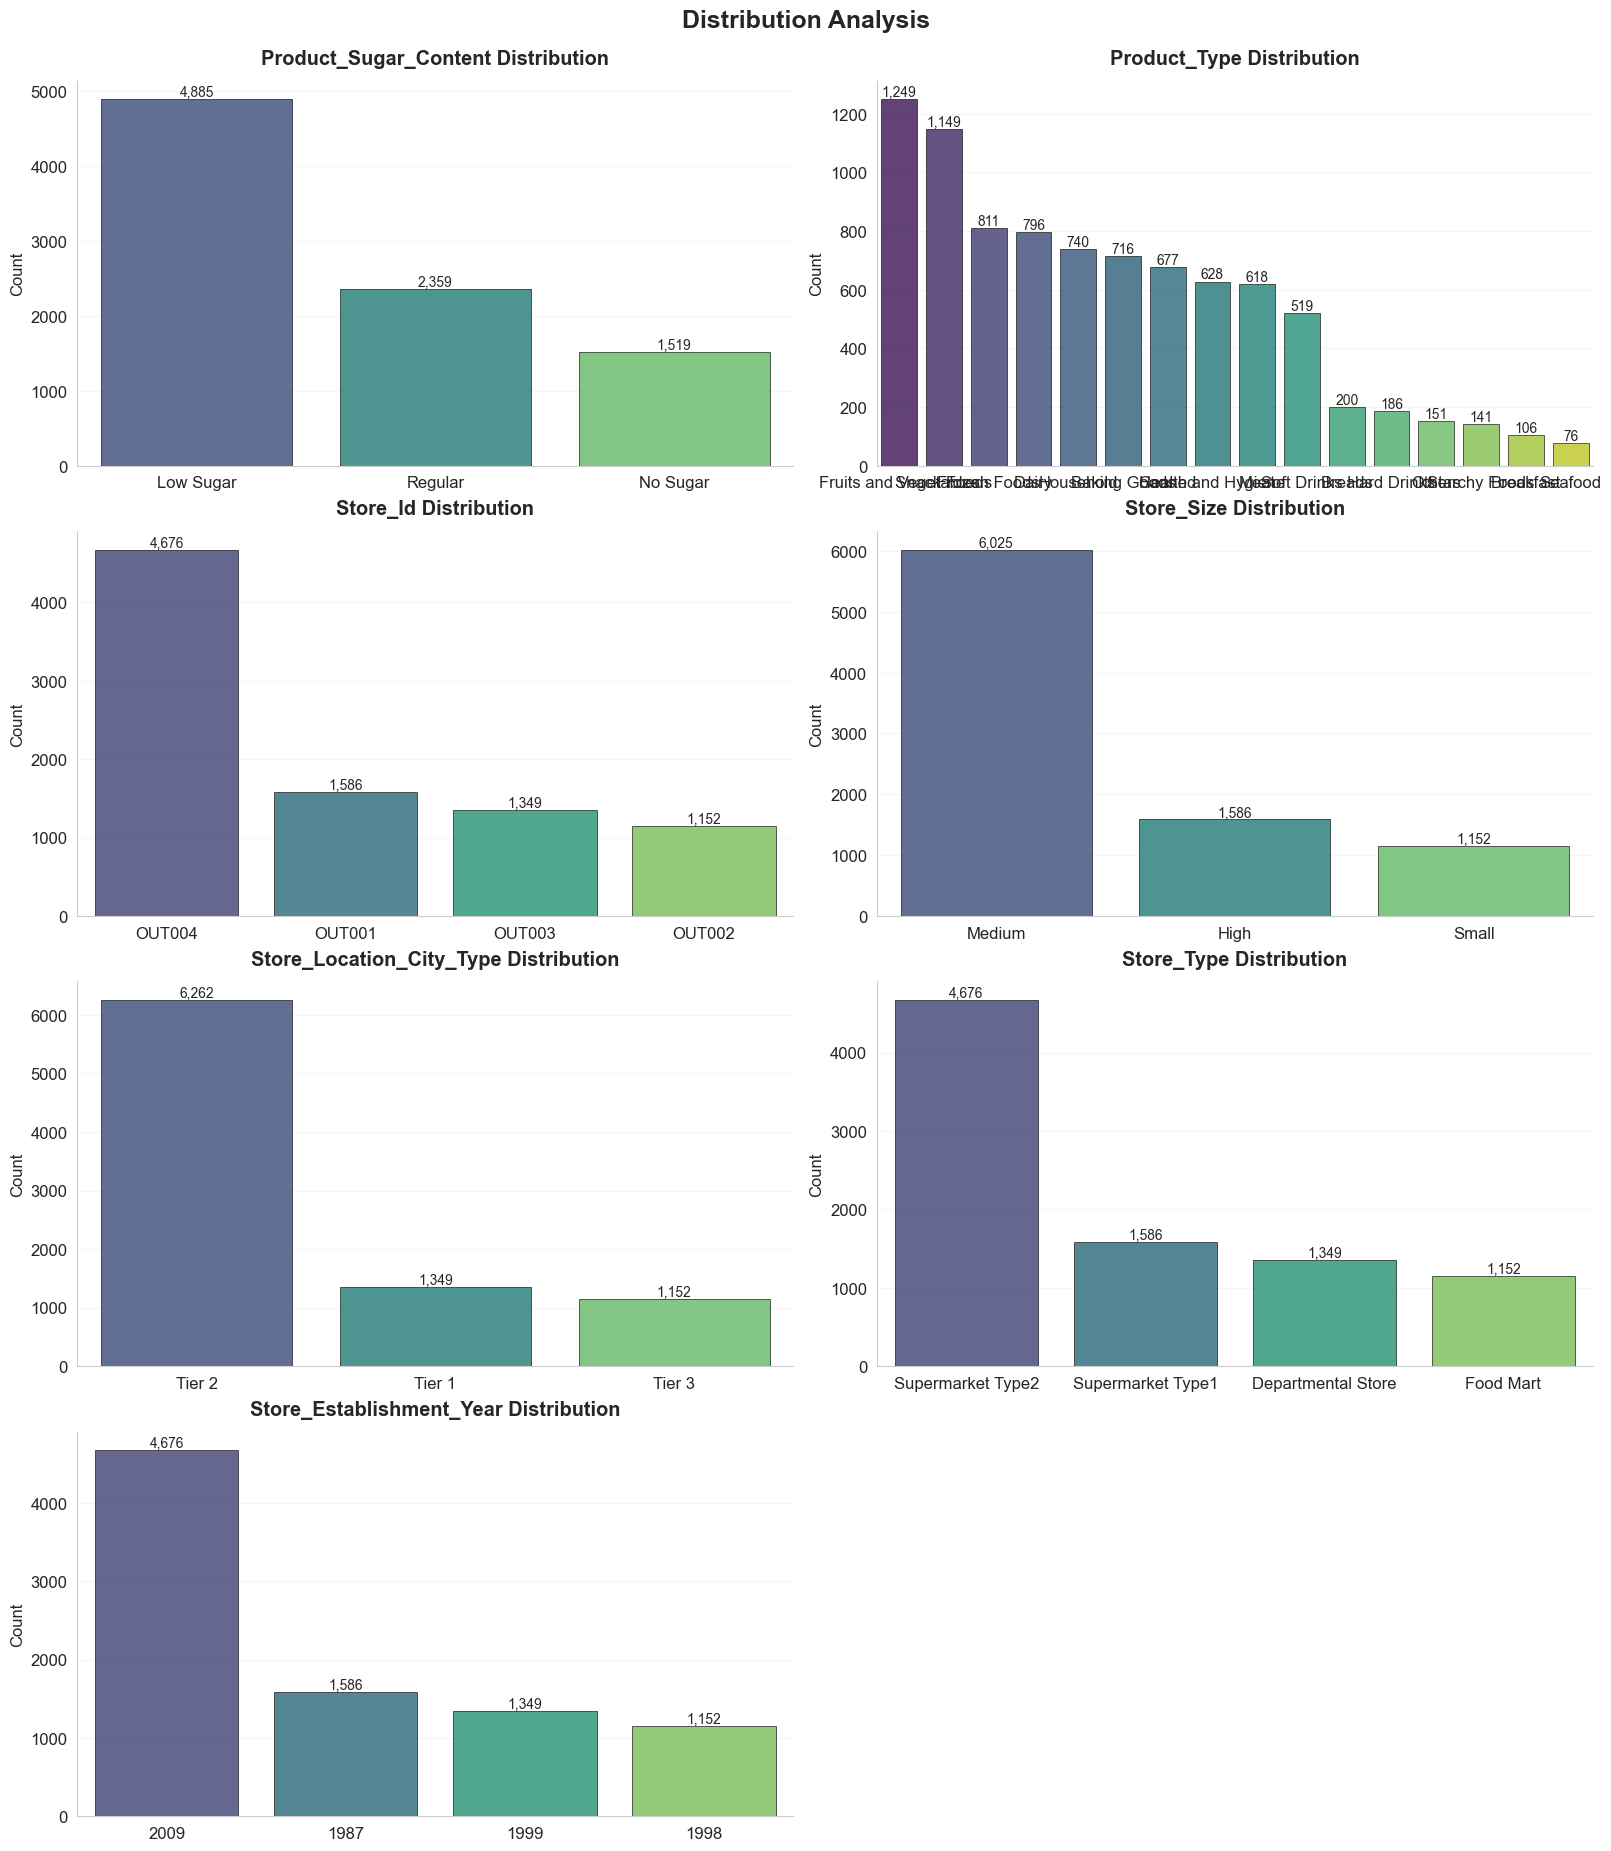

In [29]:
# Bar plots for categorical features 
fig = plot_categorical_distributions(df, plot_categorical)

#### Univariate Analysis Observations (Categorical Features)
---
**Product_Sugar_Content**
- Categories: 3 (Low Sugar, Regular, No Sugar).
- Dominant class: Low Sugar (n = 4,885; ~55.7%).
- The distribution is imbalanced, with Low Sugar products forming the majority.

**Product_Type**
- Categories: 16 distinct product groups.
- Most frequent: Fruits and Vegetables (n = 1,249; ~14.3%).
- The feature is diverse, but the distribution is uneven. A few categories (e.g., Fruits and Vegetables, Snack Foods) dominate, while others (e.g., Seafood, Breakfast) are underrepresented. This long-tail distribution may require grouping rare categories for stability.

**Store_Id**
- Categories: 4 outlets.
- Dominant store: OUT004 (n = 4,676; ~53.3%).
- The dataset is heavily skewed toward a single store.

**Store_Size**
- Categories: 3 (Medium, High, Small).
- Dominant class: Medium (n = 6,025; ~68.7%).
- Strong imbalance toward medium-sized stores. Small and high stores are underrepresented.

**Store_Location_City_Type**
- Categories: 3 (Tier 1, Tier 2, Tier 3).
- Dominant class: Tier 2 (n = 6,262; ~71.4%).
- The distribution is highly skewed toward Tier 2 cities.

**Store_Type**
- Categories: 4 (Supermarket Type1, Supermarket Type2, Departmental Store, Food Mart).
- Dominant class: Supermarket Type2 (n = 4,676; ~53.3%).
- The dataset is biased toward one store format, with other types less represented.

**Store_Establishment_Year**
- Categories: 4 distinct years (2009, 1987, 1999, 1998).
- Dominant year: 2009 with 4,676 stores (~53.3% of the dataset).
- The feature is highly imbalanced, with a strong concentration of stores established in 2009. The remaining years are more evenly distributed but represent significantly smaller proportions.
- Although stored as a numerical variable, this feature represents discrete establishment years and is better treated as categorical. Alternatively, it can be transformed into store age (e.g., current_year – establishment_year) to capture temporal effects more effectively.

## Bivariate Analysis

The analysis will begin with the construction of a pair plot to visually examine the relationships among the numerical features. Subsequently, the correlation matrix will be evaluated to quantify the strength and direction of these associations.

### Scatterplots for Numeric Features

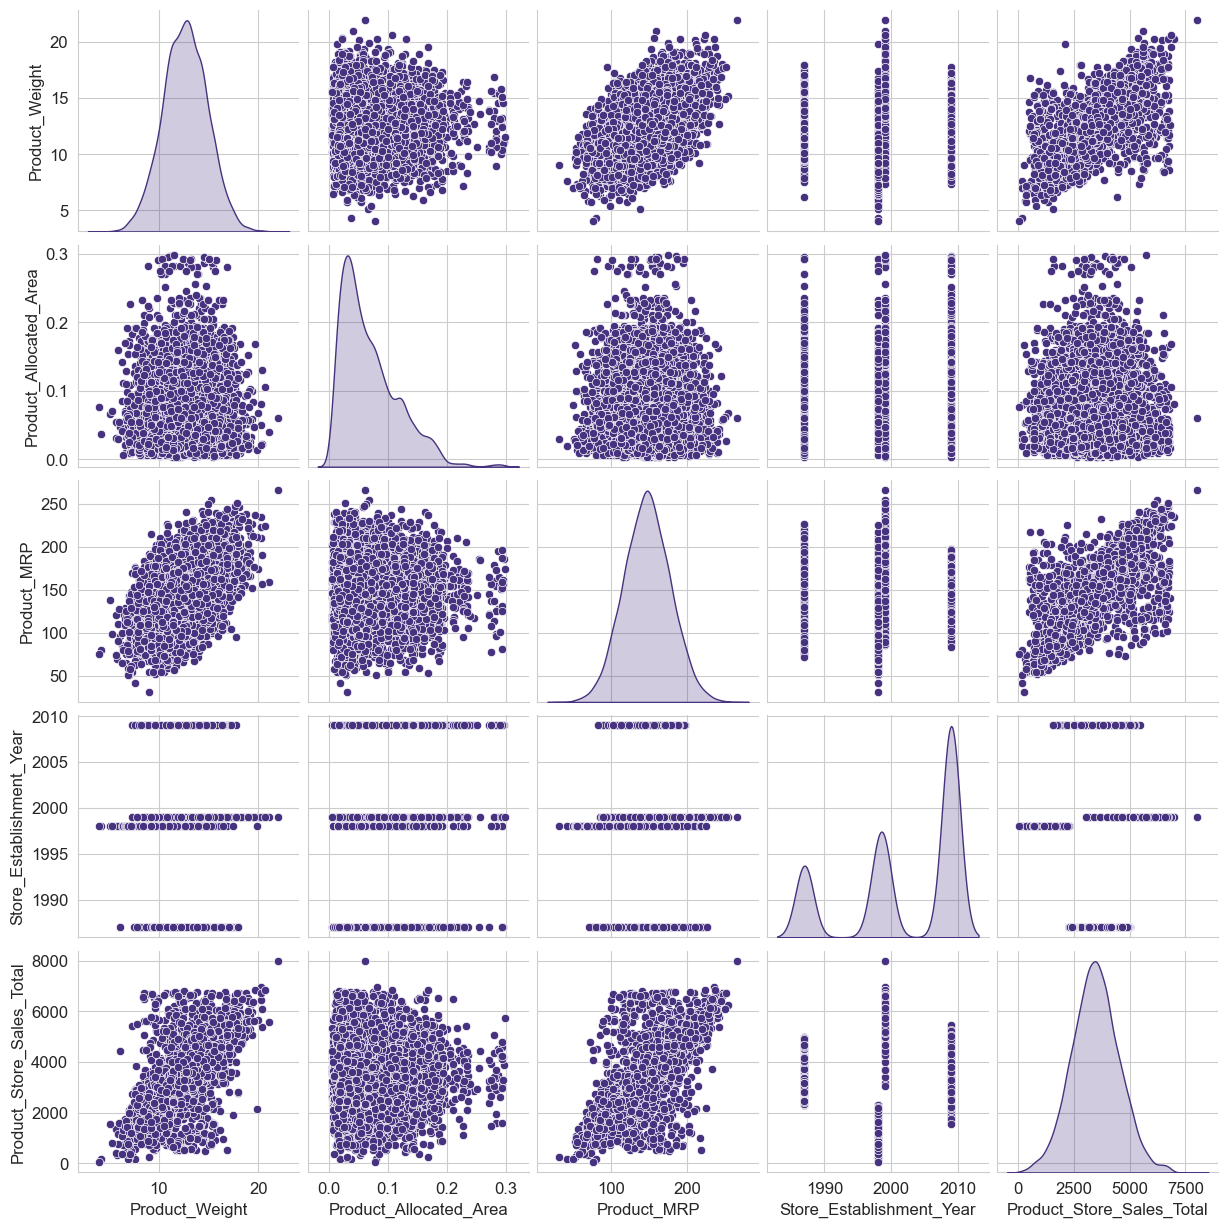

In [30]:
# Pairplot to see the relationships between numerical features
sns.pairplot(df, diag_kind='kde', palette='viridis', height=2.5)
plt.show()

### Correlation

In [31]:
# Generate the correlation Matrix
df.corr(numeric_only=True)

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total
Product_Weight,1.000000,0.014754,0.532716,-0.161907,0.737955
Product_Allocated_Area,0.014754,1.000000,-0.009508,0.004467,-0.000933
Product_MRP,0.532716,-0.009508,1.000000,-0.189357,0.787989
Store_Establishment_Year,-0.161907,0.004467,-0.189357,1.000000,-0.185027
Product_Store_Sales_Total,0.737955,-0.000933,0.787989,-0.185027,1.000000


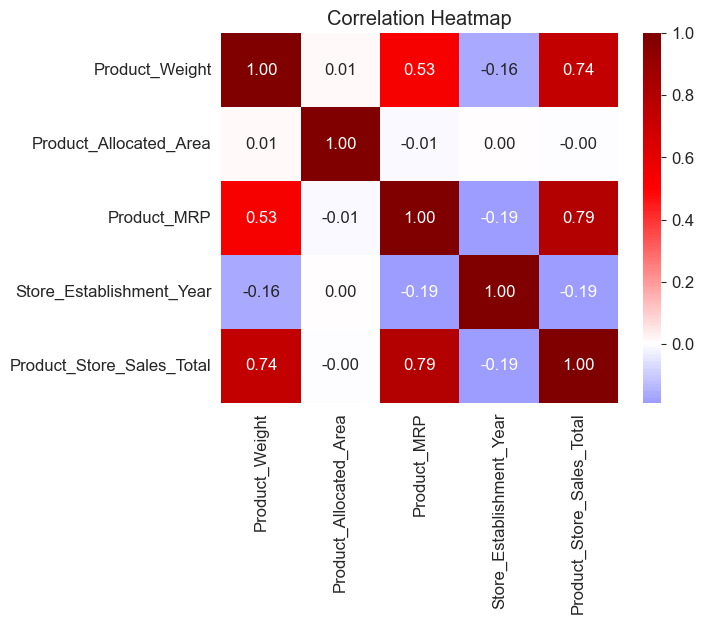

In [32]:
# Plot the correlation matrix
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="seismic", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#### Scatterplots and Correlation Observations:
---
**Product_Weight and Product_Store_Sales_Total**
- Correlation: 0.74 (strong positive)
- The scatterplot reveals a clear positive association between Product_Weight and Product_Store_Sales_Total. As product weight increases, total sales also tend to rise, suggesting that heavier products are generally linked to higher sales volumes.
- The distribution of points shows a dense clustering in the mid-range of product weights (approximately 10–15 kg) and corresponding sales totals (roughly 2,500–4,500 units). This indicates that the majority of products fall within this typical range, forming the core of the dataset.

**Product_MRP and Product_Store_Sales_Total**
- Correlation: 0.79 (strong positive)
- The scatterplot reveals a strong positive linear association between Product_MRP and Product_Store_Sales_Total. As the retail price of a product increases, its total sales also tend to rise, forming a clear upward trend.

**Product_Allocated_Area and Product_Store_Sales_Total**
- Correlation: 0.00 (No correlation)
- The majority of data points are densely clustered within the range of 0.05–0.20 for allocated area and between 1,000–6,000 units in sales.

**Product_Weight and Product_Allocated_Area**
- Correlation: 0.53 (moderate positive)
- Heavier products are generally allocated more shelf space.


### Product Store Sales Total vs Categorical Features

It is essential to examine which categories contribute most significantly to the overall Product_Store_Sales_Total. The subsequent barplots provide a visual representation of these contributions.

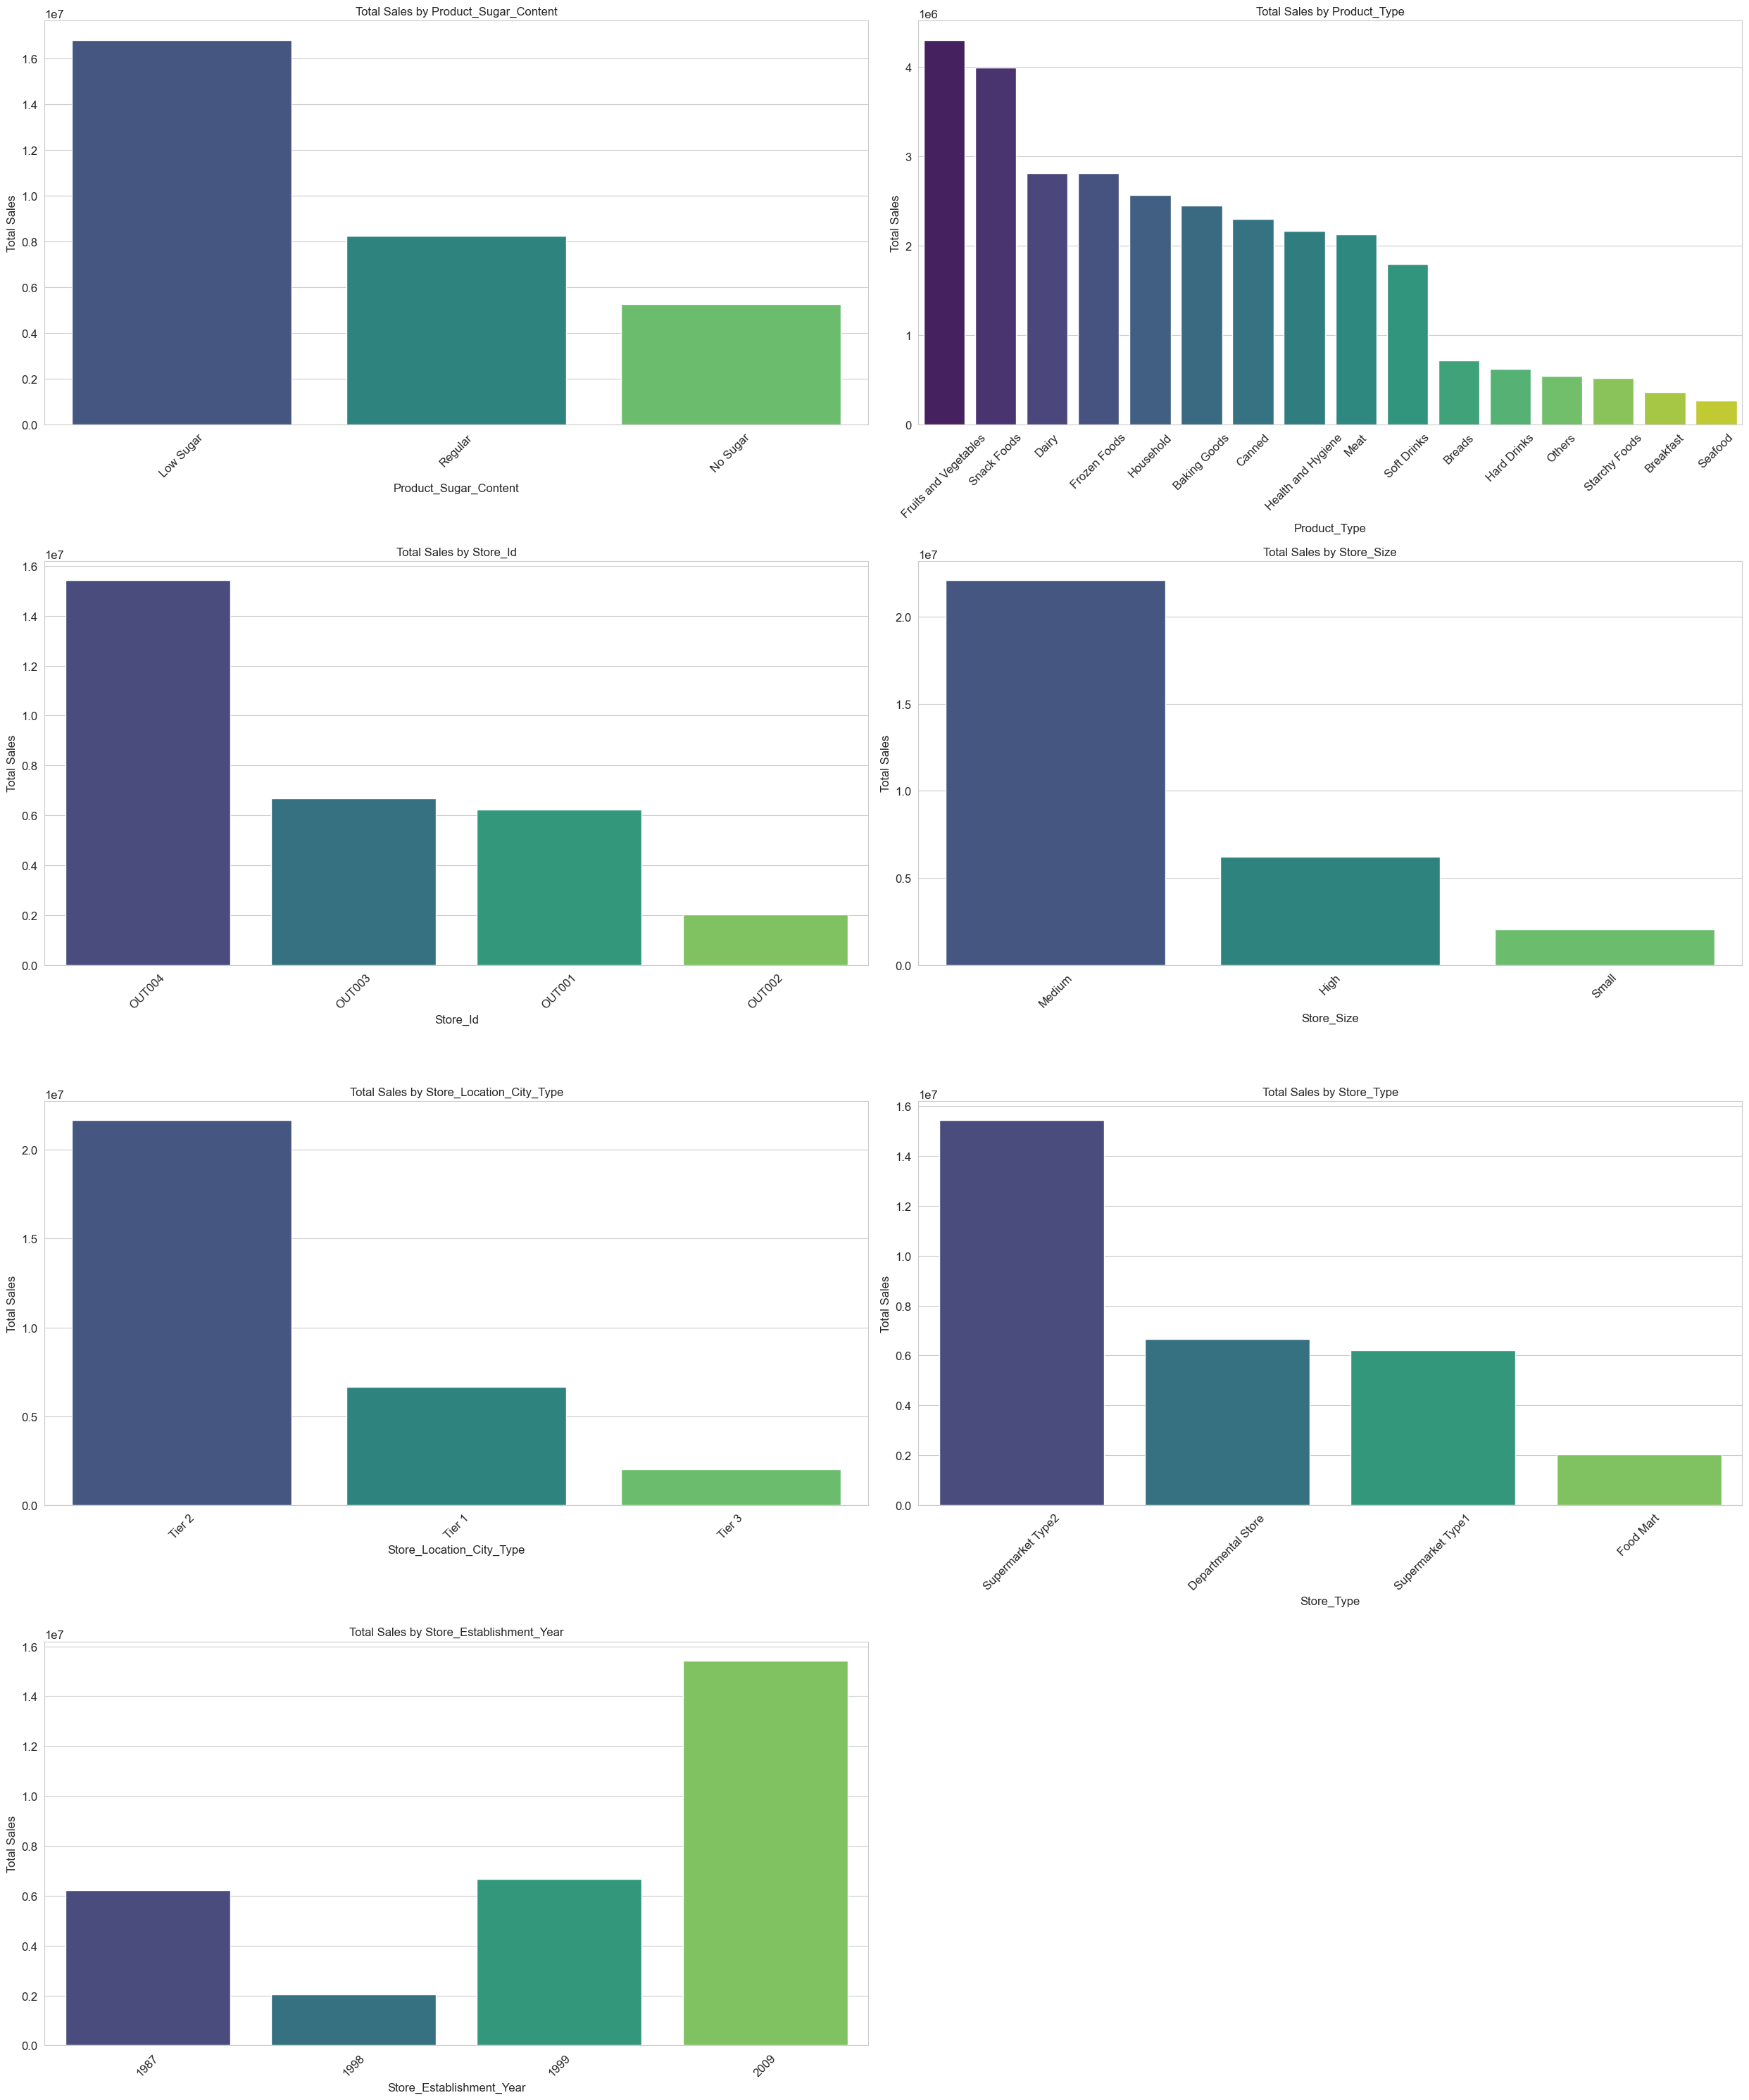

In [33]:
# Barplots of the SUM of Product_Store_Sales_Total grouped by multiple categorical variables
plot_sales_sum_multiple_categories(
    df,
    category_cols=plot_categorical,
    ncols=2,
    figsize=(25, 30)
)

### Observations
---
**Total Sales by Product Sugar Content**
- The category Low Sugar accounts for the highest total sales, significantly surpassing both Regular and No Sugar products.
- Regular sugar content products occupy the second position in total sales.
- No Sugar products contribute the least to total sales.

**Total Sales by Product Type**
- Fruits and Vegetables clearly lead in total sales, followed by Snack Foods and Dairy.These categories represent core staples and high-frequency purchases, indicating that fresh produce and everyday consumables are the primary revenue drivers for the supermarket.
- Categories such as Frozen Foods, Household, Beverages, and Canned products occupy the middle range. These categories provide steady but secondary contributions, reflecting their role as complementary purchases rather than primary shopping motivators.
- Breakfast, Seafood, and Starchy Foods show the lowest total sales. Their underperformance may be due to niche demand, higher prices, or limited assortment.
- Health and Hygiene and Household products, while not food-related, still contribute significantly.

**Total Sales by Store**
- OUT004 records the highest total sales, nearly double those of the next best-performing stores.
- Both OUT003 and OUT001 show similar sales levels, approximately half of OUT004’s total.
- OUT002 has the lowest sales, significantly trailing behind the other three stores.

**Total Sales by Store Size**
- Medium-sized stores generate the highest total sales, far exceeding both High and Small stores.
- High-sized stores record significantly lower sales than medium stores, despite their larger capacity.
- Small-sized stores contribute the least to total sales, with values far below both medium and high stores.

**Total Sales by Store Location City Type**
- Tier 2 locations generate the highest total sales, far surpassing both Tier 1 and Tier 3.
- Tier 1 cities contribute moderately to total sales, with values significantly lower than Tier 2.
- Tier 3 locations record the lowest sales, contributing only a small fraction of the total.

**Total Sales by Store Type**
- Supermarket Type2 records the highest total sales, significantly outperforming all other store types.
- Departmental Stores hold the second position in sales, though at a noticeably lower level than Supermarket Type2.
- Supermarket Type1 generates lower sales than both Supermarket Type2 and Departmental Stores.
- Food Mart contributes the least to total sales, with values far below the other store types.

**Total Sales by Store Establishment Year**
- Stores with an establishment year of 2009 record by far the highest total sales, reaching nearly 16 million.
- Both 1987 and 1999 stores show similar sales levels, slightly above 6 million each.
- Stores from 1998 show the lowest sales, slightly above 2 million.

# **7 - Data Preprocessing**

## Product_Sugar_Content Value Inconsistency

During the preliminary examination of the Product_Sugar_Content feature, the value ‘reg’ was identified. This appeared to be a data entry inconsistency and was interpreted as the intended category ‘Regular’. To ensure consistency and improve the quality of the exploratory data analysis (EDA), this issue was corrected in advance by replacing ‘reg’ with ‘Regular’.

## Feature Engineer

### Store Age
Using Store Age instead of the raw Year of Establishment provides a clearer and more stable signal for prediction. Store Age directly reflects how long a store has been operating, making it easier to interpret in terms of maturity, customer loyalty, and operational stability.


In [34]:
# Store Age feature engineering
current_year = time.localtime().tm_year
print(f"Current Year: {current_year}")
df['Store_Age'] = current_year - df['Store_Establishment_Year']
df.drop(columns=['Store_Establishment_Year'], inplace=True)

Current Year: 2025


### Product Category Grouping
Product category grouping is recommended because it reduces noise from overly granular categories, balances the dataset by aggregating small or sparse groups, and highlights broader consumer behavior patterns that are more predictive of sales.

In [35]:
# Product Category Groupings
fresh = [
    "Fruits and Vegetables",
    "Meat",
    "Seafood",
    "Dairy",
    "Breads"
]

packaged = [
    "Snack Foods",
    "Frozen Foods",
    "Baking Goods",
    "Canned",
    "Breakfast",
    "Starchy Foods"
]

beverages = [
    "Soft Drinks",
    "Hard Drinks"
]

non_consumable = [
    "Household",
    "Health and Hygiene",
    "Others"
]

In [36]:
def categorize_product_type(product_type):
    """ Categorizes product types into broader categories."""
    if product_type in fresh:
        return 'Fresh'
    elif product_type in packaged:
        return 'Packaged'
    elif product_type in beverages:
        return 'Beverages'
    else:
        return 'Non-Consumable'
# Apply the categorization function to create a new column
df['Product_Category'] = df['Product_Type'].apply(categorize_product_type)
# Drop the original Product_Type column
df.drop(columns=['Product_Type'], inplace=True)

## Outlier Check

In [37]:
# Replace Store_Establishment_Year with Store_Age in the numeric_columns list
numeric_columns[3] = 'Store_Age'

In [38]:
results = []
# Outlier detection using IQR method
for col in numeric_columns:
    # Calculate Q1, Q3, and IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    # Determine outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    # Store results
    results.append({
        'Feature': col,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outliers.shape[0],
        'Outlier Percentage': round((outliers.shape[0] / df.shape[0]) * 100, 2)
    })
outlier_df = pd.DataFrame(results)
outlier_df

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Product_Weight,6.6050,18.7250,54,0.62
1,Product_Allocated_Area,-0.0665,0.1935,104,1.19
2,Product_MRP,64.0225,229.7225,57,0.65
3,Store_Age,-0.5000,43.5000,0,0.00
4,Product_Store_Sales_Total,686.5400,6220.3400,119,1.36


**Product_Weight**
- Identified 54 outliers, representing 0.62% of the data.
- Outlier presence is relatively low, suggesting the feature is mostly stable with a few extreme values.
- As supermarkets have a varied product catalog it is correct that some products will have different weights. 

**Product_Allocated_Area**
- Identified 104 outliers, the highest count (1.19%) among all features.
- Indicates this variable has a slightly higher tendency for extreme values compared to others.

**Product_MRP**
- Identified 57 outliers, representing 0.65% of the data.
- As with product weight it makes sense that there will be differences in the pricing of products as they come from a diverse number of product categories. 

**Overall Conclusion**
- Outliers are present in all numeric features except Store_Age. The percentages are relatively small (<1.2%), suggesting that the dataset is generally clean. 
- As the supermarket has a varied number of products it is correct that products will differ in price, weight and area.
- Therefore there in no need to treat ouliers in the data.  


## Data Preparation

### Drop Product_Id
The variable Product_Id will be removed during preprocessing, as it serves only as a unique identifier and does not contain predictive information relevant to modeling Product_Store_Sales_Total. 

This column will be preserved in a new object in order to be able to use it latter for product identification. 

In [39]:
# Create a copy of the Product_Id column
product_ids = df["Product_Id"].copy()

# Drop column Case ID
df.drop("Product_Id", axis=1, inplace=True)

## Group Numeric and Categorical Features

In this stage, two distinct feature lists are constructed: one containing numerical variables and another containing categorical variables. This separation facilitates the assignment of each feature type to its appropriate preprocessing procedure within the modeling pipeline, such as applying a StandardScaler to numerical attributes and a One-Hot Encoder to categorical attributes. Furthermore, variables with an object data type are converted to the category type, a transformation that optimizes memory usage by storing categorical values more efficiently.

In [40]:
# List of numerical and categorical columns after preprocessing
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()
# Convert categorical columns to 'category' dtype
df[categorical_columns] = df[categorical_columns].astype('category')

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Product_Store_Sales_Total', 'Store_Age']
Categorical columns: ['Product_Sugar_Content', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Category']


In [41]:
# Define target variable
target = "Product_Store_Sales_Total"
numeric_columns.remove(target)

## Split Train, Validation and Test

For the modeling process, the dataset will be partitioned into three subsets: training, validation, and testing. The training set will comprise 70% of the total observations and will be used to fit the predictive models. The validation and test sets will each contain 15% of the data. The validation set will serve as the basis for hyperparameter tuning and model selection, ensuring that performance is optimized without overfitting to the training data. The test set, by contrast, will remain completely unseen during model development and will be reserved exclusively for the final evaluation of generalization performance. To facilitate subsequent batch prediction tasks, the test set will be exported as a CSV file, with the Product_Id variable reattached to preserve the ability to link predictions back to their corresponding products.

In [42]:
# Split features and target
X = df[numeric_columns + categorical_columns]
y = df[target]

In [43]:
# Split the dataset into training (70%), validation (15%), and test (15%) sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=RS
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5, 
    random_state=RS
)

In [44]:
# Print the shapes of the datasets
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (6134, 10) (6134,)
Validation set: (1314, 10) (1314,)
Test set: (1315, 10) (1315,)


### Export the test data to a CSV file

In [45]:
# Obtain the indices of the test set to merge with Product_Id
test_indices = X_test.index
product_ids_test = product_ids.loc[test_indices]
# Reattach Product_Id to the test set for batch predictions
test_data_with_id = X_test.copy()
test_data_with_id["Product_Id"] = product_ids_test
# Save the test set with Product_Id for batch predictions
test_data_with_id.to_csv(FOLDER + BATCH_FILE, index=False)

## Pre-processing Pipeline

For preprocessing, numerical features will be standardized using a StandardScaler, which transforms the variables to have zero mean and unit variance. This step ensures that features measured on different scales contribute equally to the learning process and prevents models from being biased toward variables with larger magnitudes.

For categorical features, a One-Hot Encoder will be applied to convert each category into a set of binary indicator variables. This representation avoids imposing an artificial ordinal relationship among categories while enabling the model to capture distinctions between them effectively.

In [46]:
# Pre-processing Pipeline
preprocesor = make_column_transformer(
    (StandardScaler(), numeric_columns),
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_columns)
)

# **8 - Model Building**

#### Define functions for Model Evaluation

In [47]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

## Evaluation Metric

R‑squared was selected as the primary evaluation metric for comparing different regression models because it provides a clear and standardized measure of the proportion of variance in sales revenue explained by the model. R‑squared is dimensionless and facilitates direct comparison across models regardless of the magnitude of the prediction errors.


## Model Type Selection

In this part the following models will be tested in order to chose wich models will be tune further. The models will use default parameters.

1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

In [48]:
# List to hold different models
models = []
# Adding different models to the list
models.append(("Decision Tree", make_pipeline(preprocesor, DecisionTreeRegressor(random_state=RS))))
models.append(("Bagging", make_pipeline(preprocesor, BaggingRegressor(random_state=RS))))
models.append(("Random Forest", make_pipeline(preprocesor, RandomForestRegressor(random_state=RS))))
models.append(("AdaBoost", make_pipeline(preprocesor, AdaBoostRegressor(random_state=RS))))
models.append(("Gradient Boosting", make_pipeline(preprocesor, GradientBoostingRegressor(random_state=RS))))
models.append(("XGBoost", make_pipeline(preprocesor, XGBRegressor(random_state=RS, eval_metric='rmse'))))


In [49]:
results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
scores = []
results_scores_training = []  # Empty list to store the scores of the models on training set
results_scores_validation = []  # Empty list to store the scores of the models on validation set

# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "r2"
    kfold = KFold(
        n_splits=5, shuffle=True, random_state=RS
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    
    print(f"{name}: {cv_result.mean()}")

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    score = r2_score(y_val, model.predict(X_val))
    scores.append(score)
    print(f"{name}: {score}")
    results_scores_training.append(model_performance_regression(model, X_train, y_train))
    results_scores_validation.append(model_performance_regression(model, X_val, y_val))


Cross-Validation Performance:

Decision Tree: 0.8547943907818454
Bagging: 0.91775000760329
Random Forest: 0.9234324198085797
AdaBoost: 0.7833838611516986
Gradient Boosting: 0.9113375697025156
XGBoost: 0.9151686462025438

Validation Performance:

Decision Tree: 0.8565995239112341
Bagging: 0.9303339060692224
Random Forest: 0.9372111354077355
AdaBoost: 0.7923120544611757
Gradient Boosting: 0.9222325662978764
XGBoost: 0.9280525396430076


#### Models Worth Tuning
**Random Forest**  
- Cross-validation score: 0.923; Validation score: 0.937  
- Demonstrates strong and consistent performance across both cross-validation and validation sets. Further hyperparameter optimization is expected to yield incremental improvements in predictive accuracy and model generalization.  

**Bagging**  
- Cross-validation score: 0.918; Validation score: 0.930  
- Exhibits stable and reliable results. Tuning efforts should focus on parameters such as the number of base estimators and the complexity of the underlying learners to enhance performance.  

**XGBoost**  
- Cross-validation score: 0.915; Validation score: 0.928  
- Shows highly competitive results and is well known for its sensitivity to hyperparameter adjustments. Careful optimization of learning rate, tree depth, and sampling parameters is likely to further improve predictive capability.  


## Random Forest

At this stage, a baseline Random Forest Regressor will be constructed and employed as a benchmark model. Its performance will serve as a reference point against which the results of alternative algorithms can be systematically compared.

In [50]:
# Random Forest Regressor
model_rf = RandomForestRegressor(random_state=RS)
model_pipeline_rf = make_pipeline(
    preprocesor,
    model_rf
)
# Fit the model
model_pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Product_Sugar_Content',
                                                   'Store_Id', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [51]:
# Check performance on training and validation sets
print("Training Performance of Random Forest Regressor:")
un_rf_train_performance = model_performance_regression(model_pipeline_rf, X_train, y_train)
print(un_rf_train_performance)
print("Validation Performance of Random Forest Regressor:")
un_rf_val_performance = model_performance_regression(model_pipeline_rf, X_val, y_val)
print(un_rf_val_performance)

Training Performance of Random Forest Regressor:
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  108.006907  41.150298   0.989724        0.989708  0.015364
Validation Performance of Random Forest Regressor:
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  262.401182  102.388678   0.937211        0.936729  0.037338


## Bagging Regresor

A baseline Bagging Regressor will be constructed and employed as a comparative benchmark. Its performance will serve as a reference point against which more complex ensemble techniques.

In [52]:
# Bagging Regressor
model_bag = BaggingRegressor(random_state=RS)
model_pipeline_bag = make_pipeline(
    preprocesor,
    model_bag
)
# Fit the model
model_pipeline_bag.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Product_Sugar_Content',
                                                   'Store_Id', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Category'])])),
                ('baggingregressor', BaggingRegressor(random_state=42))])

In [53]:
# Check performance on training and validation sets
print("Training Performance of Bagging Regressor:")
un_bag_train_performance = model_performance_regression(model_pipeline_bag, X_train, y_train)
print(un_bag_train_performance)
print("Validation Performance of Random Forest Regressor:")
un_bag_val_performance = model_performance_regression(model_pipeline_bag, X_val, y_val)
print(un_bag_val_performance)

Training Performance of Bagging Regressor:
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  121.389481  45.197778    0.98702        0.986999  0.016902
Validation Performance of Random Forest Regressor:
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  276.398195  112.209047   0.930334        0.929799  0.040819


## XGBoost Regresor

An XGBoost Regressor is implemented as part of the comparative modeling framework. Its performance will be evaluated against other ensemble approaches, with the expectation that careful hyperparameter optimization may further enhance predictive accuracy and generalization.

In [54]:
# XGBoost Regressor
model_xgb = XGBRegressor(random_state=RS, eval_metric='rmse')
model_pipeline_xgb = make_pipeline(
    preprocesor,
    model_xgb
)
# Fit the model
model_pipeline_xgb.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Product_Sugar_Content',
                                                   'Store_Id', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_C...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [55]:
# Check performance on training and validation sets
print("Training Performance of XGBoost Regresor:")
un_xgb_train_performance = model_performance_regression(model_pipeline_xgb, X_train, y_train)
print(un_xgb_train_performance)
print("Validation Performance of XGBoost Regressor:")
un_xgb_val_performance = model_performance_regression(model_pipeline_xgb, X_val, y_val)
print(un_xgb_val_performance)

Training Performance of XGBoost Regresor:
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  132.016274  62.136601   0.984648        0.984623  0.022337
Validation Performance of XGBoost Regressor:
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  280.887367  129.623835   0.928053          0.9275  0.046238


# **9 - Model Performance Improvement - Hyperparameter Tuning**

## Random Forest Tuning

In this section, the Random Forest model will undergo hyperparameter optimization through the application of GridSearchCV(), which systematically evaluates multiple parameter configurations to identify the combination that yields the best predictive performance.

In [ ]:
# Hyperparameter Tuning for Random Forest Regressor using GridSearchCV
rf_tuned = RandomForestRegressor(random_state=RS)

rf_pipeline_tuned = make_pipeline(
    preprocesor,
    rf_tuned
)
# Parameter grid for Random Forest Regressor
rf_param_grid = {
    'randomforestregressor__n_estimators': [250, 300, 350],
    'randomforestregressor__max_depth': [30, 40, 50],
    'randomforestregressor__min_samples_split': [8, 10, 12],
    'randomforestregressor__min_samples_leaf': [1, 2],
    'randomforestregressor__max_features': ['auto', 'sqrt', 'log2'],
    'randomforestregressor__bootstrap': [True, False]
}
# Define R-squared as the scoring metric
scorer = make_scorer(r2_score)
# Initialize GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline_tuned,
    param_grid=rf_param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)
# Fit the GridSearchCV
rf_grid_search.fit(X_train, y_train)
print("Best Parameters from Randomized Search:")
print(rf_grid_search.best_params_)

In [57]:
# Print best parameters and best score
print("Best Parameters from Randomized Search:")
print(rf_grid_search.best_params_)
print("R2 Score from best estimator:")
print(rf_grid_search.best_score_)

Best Parameters from Randomized Search:
{'randomforestregressor__bootstrap': False, 'randomforestregressor__max_depth': 30, 'randomforestregressor__max_features': 'sqrt', 'randomforestregressor__min_samples_leaf': 2, 'randomforestregressor__min_samples_split': 8, 'randomforestregressor__n_estimators': 350}
R2 Score from best estimator:
0.9106957850515564


In [58]:
# Finalize the tuned Random Forest model
rf_tuned = rf_grid_search.best_estimator_
rf_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Product_Sugar_Content',
                                                   'Store_Id', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(bootstrap=False, max_depth=30,
                                       max_features='sqrt', min_samples_leaf=2,
                                       min_samples_split=8, n_estimators=350,
                                       random_state=42))])

In [59]:
# Check performance on training and validation sets
rf_train_performance = model_performance_regression(rf_tuned, X_train, y_train)
rf_val_performance = model_performance_regression(rf_tuned, X_val, y_val)

In [60]:
# Print performance
print("Training Performance of Tuned Random Forest Regressor:")
print(rf_train_performance)
print("Validation Performance of Tuned Random Forest Regressor:")
print(rf_val_performance)

Training Performance of Tuned Random Forest Regressor:
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  169.318232  78.016462   0.974747        0.974706  0.030695
Validation Performance of Tuned Random Forest Regressor:
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  285.959518  149.498005   0.925431        0.924858  0.060119


The baseline configuration achieved very high training performance (R-squared =  0.990 and RMSE = 108) but showed a noticeable decline on the validation set (R-squared =  0.937 and RMSE = 262), indicating a degree of overfitting. 

After hyperparameter tuning, the Random Forest exhibited reduced training accuracy (R-squared =  0.975 and RMSE = 169), reflecting stronger regularization, yet validation performance also declined slightly (R-squared =  0.925 and RMSE = 286). 

The tuning reduced overfitting but at the expense of predictive accuracy on the validation set.

## Bagging Regressor Tuning

The Bagging model will be subjected to hyperparameter optimization using GridSearchCV(). This procedure systematically explores a predefined set of parameter combinations in order to determine the configuration that maximizes predictive performance.

In [ ]:
# Hyperparameter Tuning for Bagging Regressor using GridSearchCV
bag_tuned = BaggingRegressor(
    estimator=DecisionTreeRegressor(), 
    random_state=RS
)
# Create the pipeline
bag_pipeline_tuned = make_pipeline(
    preprocesor,
    bag_tuned
)
# Define the parameter grid for Bagging Regressor
bag_param_grid = {
    'baggingregressor__n_estimators': [400, 500, 600],
    'baggingregressor__max_samples': [0.6, 0.7, 0.8],
    'baggingregressor__max_features': [0.8, 0.9, 1.0],
    'baggingregressor__bootstrap': [True],
    'baggingregressor__bootstrap_features': [False],
    'baggingregressor__estimator__max_depth': [20, 30, 40],
    'baggingregressor__estimator__min_samples_split': [2, 4],
    'baggingregressor__estimator__min_samples_leaf': [1, 2, 3]
}
# Define R-squared as the scoring metric
scorer = make_scorer(r2_score)
# Create the GridSearchCV object
bag_grid_search = GridSearchCV(
    estimator=bag_pipeline_tuned,
    param_grid=bag_param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1,
)
# Fit the GridSearchCV
bag_grid_search.fit(X_train, y_train)

In [62]:
# Print best parameters and best score
print("Best Parameters from Grid Search:")
print(bag_grid_search.best_params_)
print("R2 Score from best estimator:")
print(bag_grid_search.best_score_)


Best Parameters from Grid Search:
{'baggingregressor__bootstrap': True, 'baggingregressor__bootstrap_features': False, 'baggingregressor__estimator__max_depth': 20, 'baggingregressor__estimator__min_samples_leaf': 3, 'baggingregressor__estimator__min_samples_split': 2, 'baggingregressor__max_features': 1.0, 'baggingregressor__max_samples': 0.8, 'baggingregressor__n_estimators': 600}
R2 Score from best estimator:
0.9276009825918292


In [63]:
# Finalize the tuned Bagging model
bag_tuned = bag_grid_search.best_estimator_
bag_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Product_Sugar_Content',
                                                   'Store_Id', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Category'])])),
                ('baggingregressor',
                 BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=20,
                                                                  min_samples_leaf=3),
                                  max_samples=0.8, n_estimators=600,
                                  random_state=42))])

In [64]:
# Check performance on training and validation sets
bag_train_performance = model_performance_regression(bag_tuned, X_train, y_train)
bag_val_performance = model_performance_regression(bag_tuned, X_val, y_val)

In [65]:
# Print performance
print("Training performance of tuned Bagging Regressor:")
print(bag_train_performance)
print("Validation performance of tuned Bagging Regressor:")
print(bag_val_performance)

Training performance of tuned Bagging Regressor:
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  210.171188  75.142734   0.961091        0.961027  0.028827
Validation performance of tuned Bagging Regressor:
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  254.175326  96.415361   0.941086        0.940634  0.036201


In [66]:
print(un_bag_train_performance)
print(un_bag_val_performance)

         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  121.389481  45.197778    0.98702        0.986999  0.016902
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  276.398195  112.209047   0.930334        0.929799  0.040819


The baseline model achieved stronger performance on the training set (R-squared 0.987 and RMSE = 121.39), it exhibited a larger gap when evaluated on validation data (R-squared = 0.930 and RMSE = 276), indicating moderate overfitting. 

The tuned Bagging model produced lower training accuracy (R-squared 0.961 and RMSE = 210) but delivered improved validation results (R-squared 0.941 and RMSE = 254), with reduced error and a narrower gap between training and validation metrics.  

The hyperparameter optimization successfully regularized the model, leading to better generalization and more reliable predictive performance on unseen data.

## XGBoost Regressor

The Bagging model will undergo hyperparameter optimization through the use of GridSearchCV(). This method systematically evaluates a predefined range of parameter settings to identify the configuration that yields the highest predictive accuracy.

In [ ]:
# Hyperparameter Tuning for XGBoost Regressor using GridSearchCV
xgb_tuned = XGBRegressor(random_state=RS, eval_metric='rmse')
xgb_pipeline_tuned = make_pipeline(
    preprocesor,
    xgb_tuned
)
# Define the parameter grid for XGBoost Regressor
xgb_param_grid = {
    'xgbregressor__n_estimators': [100, 120, 140],
    'xgbregressor__max_depth': [6, 7],
    'xgbregressor__learning_rate': [0.03, 0.05, 0.07],
    'xgbregressor__subsample': [0.5, 0.6, 0.7],
    'xgbregressor__colsample_bytree': [0.9, 1.0],
    'xgbregressor__gamma': [0.5, 1],
    'xgbregressor__reg_alpha': [0, 0.1],
    'xgbregressor__reg_lambda': [2, 3]
}
# Define R-squared as the scoring metric
scorer = make_scorer(r2_score)
# Create the GridSearchCV object
xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline_tuned,
    param_grid=xgb_param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1,
)
# Fit the GridSearchCV
xgb_grid_search.fit(X_train, y_train)

In [68]:
# Print best parameters and best score
print("Best Parameters for XGBoost Regresor:")
print(xgb_grid_search.best_params_)
print("R2 Score from best estimator:")
print(xgb_grid_search.best_score_)

Best Parameters for XGBoost Regresor:
{'xgbregressor__colsample_bytree': 1.0, 'xgbregressor__gamma': 0.5, 'xgbregressor__learning_rate': 0.05, 'xgbregressor__max_depth': 7, 'xgbregressor__n_estimators': 100, 'xgbregressor__reg_alpha': 0.1, 'xgbregressor__reg_lambda': 2, 'xgbregressor__subsample': 0.7}
R2 Score from best estimator:
0.9267537495277149


In [69]:
# Finalize the tuned XGBoost model
xgb_tuned = xgb_grid_search.best_estimator_
xgb_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Product_Sugar_Content',
                                                   'Store_Id', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_C...
                              feature_types=None, feature_weights=None,
                              gamma=0.5, grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=7, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [70]:
# Check performance on training and validation sets
xgb_train_performance = model_performance_regression(xgb_tuned, X_train, y_train)
xgb_val_performance = model_performance_regression(xgb_tuned, X_val, y_val)

In [71]:
# Print performance
print("Training XGBoost Regressor Performance:")
print(xgb_train_performance)
print("Validation XGBoost Regressor Performance:")
print(xgb_val_performance)

Training XGBoost Regressor Performance:
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  221.918994  86.724076    0.95662        0.956549  0.032791
Validation XGBoost Regressor Performance:
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  257.434084  106.055493   0.939566        0.939102  0.039791


In [72]:
print(un_xgb_train_performance)
print(un_xgb_val_performance)

         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  132.016274  62.136601   0.984648        0.984623  0.022337
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  280.887367  129.623835   0.928053          0.9275  0.046238


The baseline configuration achieved higher training accuracy (R-squared = 0.985 and RMSE = 132) but exhibited a larger performance gap when evaluated on the validation set (R-squared =  0.928 and RMSE ≈ 281), indicating moderate overfitting. 

After tuning, the model’s training performance decreased (R-squared = 0.957 and RMSE ≈ 222), reflecting stronger regularization, while validation performance improved (R-squared = 0.940 and RMSE ≈ 257), with lower error and a narrower gap between training and validation metrics. 

This outcome demonstrates that tuning successfully reduced overfitting and enhanced the model’s generalization capacity, yielding more reliable predictive performance on unseen data.

# **10 - Model Performance Comparison, Final Model Selection, and Serialization**

## Model Performance Comparison

This section presents a comparative table summarizing the performance of all evaluated models, with the objective of identifying the most suitable model for selection.

### Train Performance Comparison

In [73]:
# Compare training performance of the tuned models
model_trian_comparison = pd.concat(
    [
        un_rf_train_performance.T,
        un_bag_train_performance.T,
        un_xgb_train_performance.T,
        rf_train_performance.T,
        bag_train_performance.T, 
        xgb_train_performance.T
    ], 
    axis=1,
)
# Set the column names
model_trian_comparison.columns = ['Random Forest', 'Bagging Regressor', 'XGBoost Regressor', 
                                 'Tuned Random Forest', 'Tuned Bagging Regressor', 'Tuned XGBoost Regressor']

# Display the comparison
print("Training Performance Comparison of Tuned Models:")
model_trian_comparison

Training Performance Comparison of Tuned Models:


,Random Forest,Bagging Regressor,XGBoost Regressor,Tuned Random Forest,Tuned Bagging Regressor,Tuned XGBoost Regressor
RMSE,108.006907,121.389481,132.016274,169.318232,210.171188,221.918994
MAE,41.150298,45.197778,62.136601,78.016462,75.142734,86.724076
R-squared,0.989724,0.987020,0.984648,0.974747,0.961091,0.956620
Adj. R-squared,0.989708,0.986999,0.984623,0.974706,0.961027,0.956549
MAPE,0.015364,0.016902,0.022337,0.030695,0.028827,0.032791


### Validation Performance Comparison

In [74]:
# Compare validation performance of the tuned models
model_val_comparison = pd.concat(
    [
        un_rf_val_performance.T,
        un_bag_val_performance.T,
        un_xgb_val_performance.T,
        rf_val_performance.T,
        bag_val_performance.T, 
        xgb_val_performance.T
    ],
    axis=1,
)
# Set the column names
model_val_comparison.columns = ['Random Forest', 'Bagging Regressor', 'XGBoost Regressor', 
                               'Tuned Random Forest', 'Tuned Bagging Regressor', 'Tuned XGBoost Regressor']

# Display the comparison
print("Validation Performance Comparison of Tuned Models:")
model_val_comparison

Validation Performance Comparison of Tuned Models:


,Random Forest,Bagging Regressor,XGBoost Regressor,Tuned Random Forest,Tuned Bagging Regressor,Tuned XGBoost Regressor
RMSE,262.401182,276.398195,280.887367,285.959518,254.175326,257.434084
MAE,102.388678,112.209047,129.623835,149.498005,96.415361,106.055493
R-squared,0.937211,0.930334,0.928053,0.925431,0.941086,0.939566
Adj. R-squared,0.936729,0.929799,0.927500,0.924858,0.940634,0.939102
MAPE,0.037338,0.040819,0.046238,0.060119,0.036201,0.039791


### Overfitting Check

In [75]:
# Check for overfitting by comparing training and validation R-squared
print("Overfitting Check (R-squared difference between Training and Validation):")
(model_trian_comparison - model_val_comparison).iloc[2]

Overfitting Check (R-squared difference between Training and Validation):


Random Forest              0.052513
Bagging Regressor          0.056686
XGBoost Regressor          0.056596
Tuned Random Forest        0.049316
Tuned Bagging Regressor    0.020005
Tuned XGBoost Regressor    0.017054
Name: R-squared, dtype: float64

## Model Selection
---
- The comparative analysis of all models indicates that while the baseline Random Forest and Bagging regressors achieved higher training accuracy, they exhibited larger gaps between training and validation performance, reflecting moderate overfitting.
- In contrast, the tuned models introduced stronger regularization, reducing this gap and improving generalization.
- Among all evaluated models, the Tuned Bagging Regressor achieved the highest validation accuracy (R-squared = 0.941) with the lowest error metrics, making it the strongest performer in predictive terms. 
- However, the Tuned XGBoost Regressor demonstrated the smallest train–validation gap (0.017) while maintaining strong validation accuracy (R-squared = 0.940 and RMSE ≈ 257), indicating superior generalization stability.
- Taken together, these results suggest that while Tuned Bagging offers the best predictive accuracy on the validation set, Tuned XGBoost provides the most robust balance between accuracy and generalization.
- **The Tuned XGBoost is the preferred model, as its superior generalization capacity ensures more consistent and dependable predictive performance.**

## Tuned XGBoost Testing Performance

Finally, the Tuned XGBoost model will be evaluated on the unseen test dataset to provide an unbiased measure of its predictive performance and confirm its generalization capability.

In [76]:
xgb_test_performance = model_performance_regression(xgb_tuned, X_test, y_test)
print("Test Performance of Tuned XGBoost Regressor:")
print(xgb_test_performance)

Test Performance of Tuned XGBoost Regressor:
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  299.300058  118.17161   0.923728        0.923143  0.044654


The evaluation of the Tuned XGBoost Regressor on the unseen test dataset demonstrates that the model generalizes effectively beyond the training and validation phases. With an R-squared of 0.924, the model maintains strong predictive accuracy while avoiding significant performance degradation. These results confirm that the Tuned XGBoost achieves a robust balance between accuracy and generalization, validating its selection as the most reliable model for deployment.

## Model Serialization

In this section the tuned XGBoost model will be serialized and saved for deployment. 

In [77]:
# Create a folder for storing the files needed for backend
os.makedirs("backend_files", exist_ok=True)

In [78]:
# Serialize the tuned XGBoost model
saved_model_path = "backend_files/xgb_tuned_model.joblib"
joblib.dump(xgb_tuned, saved_model_path)
print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at backend_files/xgb_tuned_model.joblib


In [79]:
# Load the saved model to verify
saved_model = joblib.load(saved_model_path)
print("Model loaded successfully.")
saved_model

Model loaded successfully.


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Product_Sugar_Content',
                                                   'Store_Id', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_C...
                              feature_types=None, feature_weights=None,
                              gamma=0.5, grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=7, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [80]:
# Verify the loaded model by making predictions on the test set
saved_model.predict(X_test)

array([3817.7844, 2898.2617, 2569.284 , ..., 1388.1571, 3775.216 ,
       3758.75  ], shape=(1315,), dtype=float32)

# **11 - Deployment - Backend**

For deployment, a backend architecture will be implemented that exposes an API with three distinct endpoints. The first endpoint will provide a welcome message to verify accessibility and confirm service availability. The second endpoint will handle single prediction requests, intended to integrate with a graphical user interface (GUI) through which users can submit product data via a structured form. The third endpoint will support batch processing by accepting files as input, thereby enabling efficient large‑scale prediction workflows. 

## Flask Web Framework


In [81]:
%%writefile backend_files/app.py
# Import necessary libraries
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API

# Initialize the Flask application
superkart_api = Flask("SuperKart Sale Revenue Forecasting API")
# Load the trained model
model = joblib.load("xgb_tuned_model.joblib")

# Define the home route
@superkart_api.get('/')
def home():
    return "Welcome to the SuperKart Sale Revenue Forecasting API!"

# Define the prediction route
@superkart_api.post('/v1/predict')
def predict_revenue():
    # Get the JSON data from the request
    product_data = request.get_json()
    # Create a sample input for prediction
    sample = {
        "Product_Weight": product_data["Product_Weight"],
        "Product_Allocated_Area": product_data["Product_Allocated_Area"],
        "Product_MRP": product_data["Product_MRP"],
        "Store_Age": product_data["Store_Age"],
        "Product_Sugar_Content": product_data["Product_Sugar_Content"],
        "Store_Id": product_data["Store_Id"],
        "Store_Size": product_data["Store_Size"],
        "Store_Location_City_Type": product_data["Store_Location_City_Type"],
        "Store_Type": product_data["Store_Type"],
        "Product_Category": product_data["Product_Category"],
    }
    # Convert the sample input into a DataFrame
    input_data = pd.DataFrame([sample])
    # Make prediction using the loaded model
    predicted_revenue = model.predict(input_data)[0]
    # Return the prediction as a JSON response
    return jsonify({"Predicted Sales Revenue": round(float(predicted_revenue), 2)})

# Define the batch prediction route
@superkart_api.post('/v1/batch_predict')
def batch_predict_revenue():
    # Get the file from the request
    file = request.files['file']
    input_data = pd.read_csv(file)
    # Make predictions using the loaded model
    predicted_revenue = model.predict(input_data).tolist()
    # Round the predictions to 2 decimal places
    predicted_revenue_rounded = [round(float(rev), 2) for rev in predicted_revenue]
    # Extract Product_Id for mapping predictions
    property_ids = input_data["Product_Id"].tolist()
    # Create a dictionary mapping Product_Id to predicted revenue
    output_dict = dict(zip(property_ids, predicted_revenue_rounded))
    # Return the predictions as a JSON response
    return output_dict

# Run the Flask application
if __name__ == "__main__":
    superkart_api.run(debug=True)

Overwriting backend_files/app.py


## Dependencies File

For deploying the model it is of great importance to create a requirements.txt file inside the backend_files directory, which specifies the exact versions of all dependencies required for the backend system. This file ensures reproducibility and consistency across environments by locking the versions of key libraries.

In [82]:
%%writefile backend_files/requirements.txt
pandas==2.2.3
numpy==2.2.4
scikit-learn==1.6.1
xgboost==3.0.1
joblib==1.4.2
Werkzeug==3.1.3
Flask==3.1.0
gunicorn==23.0.0
requests==2.32.5
uvicorn[standard]

Overwriting backend_files/requirements.txt


## Dockerfile

This code defines a Dockerfile that specifies the environment and execution instructions for deploying the backend application. It begins by pulling the official Python 3.13.2 base image to ensure a consistent runtime. The working directory inside the container is set to /app, and all project files from the local directory are copied into this location.

In [83]:
%%writefile backend_files/Dockerfile
FROM python:3.13.2

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `app`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_api"]

Overwriting backend_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

In this stage, a new Hugging Face Space will be created to serve as the hosting environment for the API.

In [84]:
# Authenticate to Hugging Face Hub
login(token=API_KEY)

In [85]:
# Try to create the repository for the Hugging Face Space
try:
    create_repo(
        "superkart-backend",  # One can replace "Backend_Docker_space" with the desired space name
        repo_type="space",  # Specify the repository type as "space"
        space_sdk="docker",  # Specify the space SDK as "docker" to create a Docker space
        private=False  # Set to True if you want the space to be private
    )
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

Error creating repository: 409 Client Error: Conflict for url: https://huggingface.co/api/repos/create (Request ID: Root=1-68d9d010-70a8c85273eb36083cd2dab1;3e730ddf-9660-4608-9376-20490bf90026)

You already created this space repo


## Uploading Files to Hugging Face Space (Docker Space)

In [86]:
# Define the repository ID for the Hugging Face Space
repo_id = "ferruss/superkart-backend"  
# Initialize the Hugging Face API
api = HfApi()
# Upload the folder containing the backend files to the Hugging Face Space repository
api.upload_folder(
    folder_path="backend_files",  # Local path to the folder containing files to upload
    repo_id=repo_id,  # Repository ID on Hugging Face Hub
    repo_type="space",  # Type of repository (space in this case)
)

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/spaces/ferruss/superkart-backend/commit/154e09e1b4b9fe5c96a7af89a3369813a6633055', commit_message='Upload folder using huggingface_hub', commit_description='', oid='154e09e1b4b9fe5c96a7af89a3369813a6633055', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/ferruss/superkart-backend', endpoint='https://huggingface.co', repo_type='space', repo_id='ferruss/superkart-backend'), pr_revision=None, pr_num=None)

## Backend URL

The following section presents the backend URLs corresponding to each endpoint of the SuperKart API.

In [87]:
# Define model URLs for making predictions
BACKEND_HOME_URL = "https://ferruss-superkart-backend.hf.space"
BACKEND_PREDICTION_URL = BACKEND_HOME_URL + "/v1/predict"
BACKEND_BATCH_URL = BACKEND_HOME_URL + "/v1/batch_predict"

print("Backend Home URL:", BACKEND_HOME_URL)
print("Backend Prediction URL:", BACKEND_PREDICTION_URL)
print("Backend Batch Prediction URL:", BACKEND_BATCH_URL)

Backend Home URL: https://ferruss-superkart-backend.hf.space
Backend Prediction URL: https://ferruss-superkart-backend.hf.space/v1/predict
Backend Batch Prediction URL: https://ferruss-superkart-backend.hf.space/v1/batch_predict


# **12 - Deployment - Frontend**

## Streamlit for Interactive UI

Streamlit will be employed to develop an interactive user interface for the application. The first component of the interface will consist of a structured form that enables users to input product features. Upon completion, a ‘Predict’ button will trigger a POST request to the backend, where the captured data will be processed by the predictive model to estimate sales revenue, and the resulting value will be returned and displayed on the frontend. The second component will provide functionality for batch predictions by allowing users to upload a file containing multiple product records, which will then be processed collectively by the backend model.

In [88]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [89]:
%%writefile frontend_files/app.py
import streamlit as st
import pandas as pd
import requests

# Set page configuration
st.set_page_config(page_title="SuperKart Sales Revenue Prediction", layout="wide")
# Page title
st.title("SuperKart Sales Revenue Prediction")
# Page subheader
st.subheader("Single Prediction")
# Input fields for user to enter product and store details
product_weight = st.number_input("Product Weight", min_value=0.1, max_value=25.0, step=0.1, value=12.15)
product_allocated_area = st.number_input("Product Allocated Area", min_value=0.000, max_value=0.400, step=0.001, value=0.150)
product_mrp = st.number_input("Product MRP", min_value=20.0, max_value=500.0, step=0.1, value=27.0)
store_age = st.number_input("Store Age", min_value=0, max_value=50, step=1, value=16)
product_sugar_content = st.selectbox("Product Sugar Content", options=["Low Sugar", "Regular", "No Sugar"], index=1)
store_id = st.selectbox("Store Id", options=["OUT001", "OUT002", "OUT003", "OUT004"], index=0)
store_size = st.selectbox("Store Size", options=["Small", "Medium", "High"], index=1)
store_location_city_type = st.selectbox("Store Location City Type", options=["Tier 1", "Tier 2", "Tier 3"], index=0)
store_type = st.selectbox("Store Type", options=["Food Mart", "Supermarket Type1", "Supermarket Type2", "Departmental Store"], index=1)
product_category = st.selectbox(
    "Product Category", 
    options=[
        'Packaged',
        'Fresh',
        'Non-Consumable',
        'Beverages'
    ],
    index=1
)
# Create a DataFrame from the input data
input_data = pd.DataFrame({
    "Product_Weight": [product_weight],
    "Product_Allocated_Area": [product_allocated_area],
    "Product_MRP": [product_mrp],
    "Store_Age": [store_age],
    "Product_Sugar_Content": [product_sugar_content],
    "Store_Id": [store_id],
    "Store_Size": [store_size],
    "Store_Location_City_Type": [store_location_city_type],
    "Store_Type": [store_type],
    "Product_Category": [product_category],
})
# Predict button to send data to the backend API for prediction
if st.button("Predict Sales Revenue"):
    # Make a POST request to the backend API
    response = requests.post("https://ferruss-superkart-backend.hf.space/v1/predict", json=input_data.to_dict(orient='records')[0])
    # Display the prediction result
    if response.status_code == 200:
        prediction = response.json()
        st.success(f"Predicted Sales Revenue: {prediction['Predicted Sales Revenue']:.2f}")
    else:
        st.error("Error in prediction. Please try again.")
# Section for batch prediction
st.subheader("Batch Prediction")
# File uploader for uploading CSV file
uploaded_file = st.file_uploader("Upload CSV file for batch prediction", type=["csv"])
# Predict button for batch prediction
if uploaded_file is not None:
    if st.button("Predict Batch"):
        # Make a POST request to the backend API for batch prediction
        response = requests.post("https://ferruss-superkart-backend.hf.space/v1/batch_predict", files={"file": uploaded_file})
        if response.status_code == 200:
            predictions = response.json()
            st.success("Batch Prediction Successful!")
            predictions_df = pd.DataFrame(list(predictions.items()), columns=["Product_Id", "Predicted Sales Revenue"])
            st.dataframe(predictions_df)
        else:
            st.error("Error in batch prediction. Please try again.")


Overwriting frontend_files/app.py


## Dependencies File

Similar to the backend, the requirements file for the frontend plays a crucial role in ensuring reproducibility and consistency. By explicitly specifying the necessary libraries and their versions, this file allows the frontend application to be deployed reliably across different systems without dependency conflicts.

In [90]:
%%writefile frontend_files/requirements.txt
pandas==2.2.3
requests==2.32.5
streamlit==1.49.1

Overwriting frontend_files/requirements.txt


## DockerFile

In the same way as the backend, the frontend also requires a Dockerfile to define its execution environment and deployment configuration. This file specifies the base image, working directory, dependencies, and startup commands necessary to containerize the application.

In [91]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.13.2-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Overwriting frontend_files/Dockerfile


## Uploading Files to Hugging Face Space (Streamlit Space)

In [92]:
repo_id = "ferruss/superkart-frontend"

api = HfApi()

api.upload_folder(
    folder_path="frontend_files",  # Local path
    repo_id=repo_id,  # Repository ID 
    repo_type="space",  # space repository
)

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/spaces/ferruss/superkart-frontend/commit/f619dd893d4fe1cb1775f43e95b7cb5f70ffcc14', commit_message='Upload folder using huggingface_hub', commit_description='', oid='f619dd893d4fe1cb1775f43e95b7cb5f70ffcc14', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/ferruss/superkart-frontend', endpoint='https://huggingface.co', repo_type='space', repo_id='ferruss/superkart-frontend'), pr_revision=None, pr_num=None)

## **Frontend URL**

The subsequent section provides the frontend URL, which grants users access to the graphical user interface (GUI) of the SuperKart application.

In [93]:
# Frontend URL
FRONTEND_URL = "https://ferruss-superkart-frontend.hf.space"
print("Frontend URL:", FRONTEND_URL)

Frontend URL: https://ferruss-superkart-frontend.hf.space


# **13 - Inferencing using the Backend API**

In this section we will be testing and evaluating the functionality of the backend API. Specifically, it will be used to validate both the single‑prediction endpoint, which processes individual product inputs submitted through the interface, and the batch‑prediction endpoint, which accepts uploaded files for large‑scale inference.

## Online Inference

A test product is specified by defining its features within a dictionary structure. This dictionary is then converted into JSON format and transmitted to the backend, where it is processed to generate a prediction.”

In [94]:
# Example payload for testing the prediction API
payload = {
    "Product_Weight": 12.15,
    "Product_Allocated_Area": 0.150,
    "Product_MRP": 27.0,
    "Store_Age": 27,
    "Product_Sugar_Content": "Regular",
    "Store_Id": "OUT0001",
    "Store_Size": "Medium",
    "Store_Location_City_Type": "Tier 1",
    "Store_Type": "Supermarket Type1",
    "Product_Category": "Packaged",
}

In [95]:
# Make a test prediction request to the backend API
response = requests.post(BACKEND_PREDICTION_URL, json=payload)

In [96]:
# Print the response
response

<Response [200]>

In [97]:
# Print the message from the response
print(response.json())

{'Predicted Sales Revenue': 2643.27}


A test product was submitted to the backend, which successfully returned a response with an HTTP status code of 200. The response message indicated that the product was predicted to achieve a sales revenue of 2,643.27.

## Batch Inference

As part of the data‑splitting process, the test subset was stored in a CSV file. To evaluate the batch prediction functionality of the backend, a sample of 20 products will be extracted from this file and submitted to the batch endpoint in order to generate the corresponding sales revenue predictions.

In [98]:
# Load the test batch data to verify
batch_data = pd.read_csv(FOLDER + BATCH_FILE)
batch_data.head()

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Age,Product_Sugar_Content,Store_Id,Store_Size,Store_Location_City_Type,Store_Type,Product_Category,Product_Id
0,11.03,0.185,183.66,16,Regular,OUT004,Medium,Tier 2,Supermarket Type2,Packaged,FD4956
1,10.76,0.035,138.59,16,Low Sugar,OUT004,Medium,Tier 2,Supermarket Type2,Packaged,FD6988
2,13.06,0.112,87.14,38,Regular,OUT001,High,Tier 2,Supermarket Type1,Fresh,FD7128
3,13.27,0.069,194.10,38,Regular,OUT001,High,Tier 2,Supermarket Type1,Fresh,FD5014
4,10.92,0.295,157.14,16,Low Sugar,OUT004,Medium,Tier 2,Supermarket Type2,Packaged,FD6279


In [99]:
# Sample 20 rows from the batch data
batch_pd = batch_data.sample(20, random_state=RS)

In [100]:
# Prepare the input for batch prediction
batch_input = {
    'file': batch_pd.to_csv(header=True, index=False).encode('utf-8')
}

In [101]:
# Make a test batch prediction request to the backend API
response = requests.post(BACKEND_BATCH_URL, files=batch_input)

In [102]:
# Print the response status code
response

<Response [200]>

In [103]:
# Transform the response JSON into a DataFrame for better visualization
predictions = response.json()
predictions_df = pd.DataFrame(list(predictions.items()), columns=["Product_Id", "Predicted Sales Revenue"])
# Display the predictions DataFrame
predictions_df

,Product_Id,Predicted Sales Revenue
0,DR5026,3077.34
1,FD1018,5080.87
2,FD1216,3323.19
3,FD1500,3203.22
4,FD2261,2652.09
5,FD2652,2179.47
6,FD3229,4700.51
7,FD3526,2987.97
8,FD5109,2778.22
9,FD5300,4567.74


The backend successfully returned an HTTP 200 status code, confirming proper execution of the request, and generated predictions for the 20 submitted samples. The response included both the corresponding Product_ID values and their associated predicted sales revenues.

# **14 - Actionable Insights and Business Recommendations**

## Conclusions
- The SuperKart backend API was successfully deployed and validated through both single and batch prediction endpoints, consistently returning correct HTTP 200 responses. The frontend, developed with Streamlit, provides an intuitive interface for individual and batch predictions, ensuring usability for both technical and business users.
- Univariate analysis showed that most numerical features are well‑behaved (Product_Weight, Product_MRP), while Product_Allocated_Area and the target variable (Product_Store_Sales_Total) are skewed and may benefit from transformation. Categorical features revealed strong imbalances, particularly in Store_Id, Store_Size, Store_Location_City_Type, and Store_Establishment_Year.
- Bivariate analysis highlighted strong positive correlations between Product_Weight and sales (0.74) and between Product_MRP and sales (0.79), confirming them as key revenue drivers. Product_Allocated_Area showed no relationship with sales, while categorical breakdowns revealed that Low Sugar products, Fruits and Vegetables, Medium stores, Tier 2 cities, Supermarket Type2, and stores established in 2009 dominate total sales.

## Actionable Insights
- Data Preprocessing: A StandardScaler was applied to normalize all numerical features in the dataset. This transformation rescales each variable to have a mean of zero and a standard deviation of one, ensuring that features measured on different scales contribute equally to the learning process.
- Feature Engineering: Store_Establishment_Year was transformed into store age and Product_Type was grouped into categories to improve model stability.
- Bias Awareness: Sales are disproportionately concentrated in OUT004, Medium stores, and Tier 2 cities, which may bias predictions if not monitored.
- Revenue Drivers: Product_Weight and Product_MRP are strong predictors of sales and should be prioritized in modeling and business strategy.
- Operational Readiness: The batch endpoint enables efficient large‑scale forecasting, confirming the system’s scalability for production use.

## Business Recommendations
- Category Management: Expand high‑performing categories (Fruits and Vegetables, Snack Foods, Dairy) and reassess underperforming ones (Seafood, Breakfast).
- Store Strategy: Replicate practices from OUT004 and Medium stores to improve performance across outlets; investigate underperformance of High‑sized stores.
- Market Expansion: Prioritize Tier 2 cities for growth while developing strategies to strengthen presence in Tier 1 and Tier 3.
- Apply discounts: Target underperforming categories like Seafood or Breakfast products with discounts to stimulate demand, or bundle this categories with high performing categories like Fruits and Vegetables.
